# Cheap LLM judge and baseline scores for NL→FOL translations (experiment D)

This notebook is a runnable demo of **`method.py`**, the baseline ("null") arm of a study on **gold-free metrics for
natural-language → first-order-logic (NL→FOL) translation**. The task: given a sentence and a candidate FOL formula,
with no gold formula available, score how likely the formula is **unfaithful** to the sentence.

`method.py` scores every item of a **shared frozen screen** (1,090 labelled items) with all the baselines the study must beat:

| family | metrics (all oriented so that *higher = more likely unfaithful*) |
|---|---|
| parse / compile | `parse_fail` |
| user's pilot structural metrics | joint-load conflict with the story (z3), arity/shape clashes, dangling / undeclared predicates, cross-system rerun Jaccard |
| round-trip (FOL→NL→compare) | LLM verbalises the formula → bidirectional NLI with the sentence, mpnet cosine, re-formalise + z3 equivalence |
| LLM-as-judge | cheap judge (gemini-2.5-flash-lite, JSON 0-100), cheap2 (gpt-4.1-nano, P(YES)), frontier judge (gemini-3.1-pro-preview), each on the **original** item and on a **nonce-disguised** copy (contamination control) |

Labels come from prover-checked equivalence to (corrected) gold: **track L** = Logic-LM outputs on FOLIO-dev
(CORRECT / ERROR / UNCERTAIN / UNPARSEABLE), **track H** = original public gold vs curated corrected gold.
The meta-evaluation reports AUROC with sentence-clustered bootstrap CIs, invariance to meaning-preserving rewrites,
contamination (orig vs disguised), a cross-fitted combination of all cheap baselines, complexity strata, coverage and cost.

**Full-run headline (track L, n = 524):** `judge_cheap_disg` AUROC **0.777 [0.720, 0.827]** (the bar), round-trip
NLI 0.710, pilot structural metrics 0.50-0.53 (negative result), cross-fitted combination of all cheap baselines 0.817.

### What this demo does
* `mini_demo_data.json` holds a curated **99-item slice** of the frozen screen (65 track-L items grouped by sentence
  across the 3 Logic-LM systems, 34 track-H items), the frozen rewrites/disguises, **all cached per-item outputs of the
  API and local-GPU LLM stages**, the pre-registration, and the original `src/` helper package (written to `./src`).
* Stages that need **only CPU** are **re-run live**: labeller regression, rewrites + disguise (`prep`), pilot structural
  metrics, round-trip NLI/embedding, re-formalisation equivalence and the complete `analysis` stage.
* Stages that call the OpenRouter API or a local GPU LLM (judges, verbaliser, recall probe) are shown with their
  original code, but their outputs are taken from the cached score files (the original run spent $2.02 of API).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# NOT pre-installed on Colab -> always install
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3', 'sentence-transformers==6.1.0')
_pip('https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl')

# Pre-installed on Colab -> install locally only, at Colab's exact versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0',
         'statsmodels==0.14.6', 'nltk==3.9.1', 'spacy==3.8.11', 'transformers==5.0.0', 'tokenizers==0.22.2',
         'huggingface_hub==1.4.0', 'requests==2.32.4', 'tqdm==4.67.3', 'aiohttp==3.13.3')
    _pip('torch==2.9.0', '--index-url', 'https://download.pytorch.org/whl/cpu')

In [2]:
from __future__ import annotations

import argparse
import asyncio
import json
import os
import sys
import time
from collections import Counter
from pathlib import Path

# --- notebook additions: plotting / tables for the final summary
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-1/experiment-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f"screen items: {len(data['screen_items'])}; frozen rewrites: {len(data['invariance_items_frozen'])}; "
      f"cached score files: {sorted(data['scores'])}")

Curated 100-item slice of the SHARED FROZEN SCREEN (experiment D: disguised cheap judge + all baselines for gold-free NL->FOL faithfulness). Track L = Logic-LM FOLIO-dev candidates grouped by sentence (all 3 systems), track H = curated original-vs-corrected public gold. Includes the frozen rewrites/disguises, every cached per-item score of the LLM stages (API + local GPU), the pre-registration, and the original src/ helper package (verbatim) that method.py imports.
screen items: 99; frozen rewrites: 30; cached score files: ['judge_cheap', 'judge_cheap2', 'judge_local_llama8b', 'judge_local_qwen14b', 'judge_local_qwen8b', 'judge_strong', 'pilot', 'recall_probe', 'recall_probe_local', 'roundtrip_llm', 'roundtrip_llm_local', 'roundtrip_nli', 'roundtrip_nli_local', 'rt_equiv', 'rt_equiv_local']


### Materialise the workspace layout `method.py` expects
`method.py` reads and writes a fixed layout (`src/`, `data/`, `results/scores/`, `logs/`). This cell recreates it in the
current directory from the loaded `data` bundle — this replaces the hard-coded workspace paths of the original run:

* `src/…` – the original helper package (parser + z3, labeller, disguise, rewrites, pilot metrics, round-trip NLI, judges, analysis/report), **verbatim**.
* `data/screen_items.json` – the 99-item slice of the frozen screen (keeps the frozen order).
* `results/scores/*.jsonl` – cached outputs of every LLM stage (API judges, local GPU judges, verbaliser, recall probe) for these items.
  CPU stages below recompute `pilot`, `roundtrip_nli` and `rt_equiv` and overwrite their files.
* pre-registration (`prereg.json`), dev-slice ids, label-vector sha1, iter-3 census rows for the labeller regression.

In [5]:
WORK = Path.cwd()
for rel, txt in data["src_files"].items():          # original src/ package, verbatim
    p = WORK / rel
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text(txt)
for rel, txt in data["files"].items():              # prereg, sha1s, promptdev, census rows ...
    p = WORK / rel
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text(txt)
(WORK / "data").mkdir(exist_ok=True)
(WORK / "data" / "screen_items.json").write_text(json.dumps(data["screen_items"], ensure_ascii=False, indent=1))
(WORK / "results" / "scores").mkdir(parents=True, exist_ok=True)
for name, rows in data["scores"].items():           # cached LLM-stage outputs
    (WORK / "results" / "scores" / f"{name}.jsonl").write_text("".join(json.dumps(r, ensure_ascii=False) + "\n" for r in rows))
(WORK / "results" / "costs.jsonl").write_text("".join(json.dumps(r) + "\n" for r in data["costs_api"]))
if str(WORK) not in sys.path:
    sys.path.insert(0, str(WORK))

# NLTK corpora + spaCy model used by the disguise / rewrite steps (the original run shipped them in data/nltk_data)
import nltk
for pkg in ("words", "wordnet", "omw-1.4"):
    nltk.download(pkg, download_dir=str(WORK / "data" / "nltk_data"), quiet=True)
os.environ["NLTK_DATA"] = str(WORK / "data" / "nltk_data")      # also inherited by spawned worker processes
nltk.data.path.insert(0, str(WORK / "data" / "nltk_data"))
print(sorted(str(p.relative_to(WORK)) for p in (WORK / "src").rglob("*.py")))

['src/__init__.py', 'src/analysis.py', 'src/budget.py', 'src/common.py', 'src/disguise.py', 'src/judges.py', 'src/labeller/__init__.py', 'src/labeller/fol.py', 'src/labeller/labeller.py', 'src/labeller/repair_census.py', 'src/local_llm.py', 'src/pilot_metrics.py', 'src/report.py', 'src/rewrites.py', 'src/roundtrip.py', 'src/screen.py']


## Configuration
All tunable parameters of the demo. Original values of the full run are given in the comments.

In [6]:
N_LABELLER_PAIRS = 30   # iter-3 census pairs re-labelled in the labeller regression (original: all 99)
RUN_T1_TESTS = False     # original ran tests/test_labeller.py, which reads the raw FOLIO file (not shipped) -> skipped
N_REWRITE_BASE = 15      # track-L CORRECT items used as bases for invariance rewrites (original: 150;
                         # the bundle carries frozen rewrites + cached judge scores for the first 15 bases)
RUN_NLI = False          # re-run bidirectional NLI (2x DeBERTa-v3-large) + mpnet cosine on CPU (original: GPU, all items)
                         # (~6.5 min on 2 CPUs for all 129 items -> too slow for the 10-min demo budget)
                         # False -> keep the cached roundtrip_nli.jsonl scores and re-check N_NLI_CHECK items live
N_NLI_CHECK = 32         # items whose rt_nli_min is recomputed live with the main NLI model when RUN_NLI=False
WORKERS_CAP = 6          # process-pool size cap (original: min(6, CPUs-1))

## 1. Header of `method.py`: environment, shared helpers, logging
Original lines 29-65. Only change: `Path(__file__)` (undefined in a notebook) → `Path.cwd()`, and the worker count
uses `WORKERS_CAP`. `src.common` defines `ROOT` = the directory containing `src/`, i.e. the notebook's working directory.

In [7]:
os.environ.setdefault("PYTHONHASHSEED", "0")
os.environ.setdefault("NLTK_DATA", str(Path.cwd() / "data" / "nltk_data"))
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
sys.setrecursionlimit(10000)

from loguru import logger  # noqa: E402

from src.common import DATA, LOGS, RES, ROOT, SRC_DATA, detect_cpus, jdump, jload, norm, read_jsonl, sha1, set_ram_limit  # noqa: E402

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(str(LOGS / "run.log"), rotation="30 MB", level="DEBUG")

NUM_CPUS = detect_cpus()
WORKERS = max(1, min(WORKERS_CAP, NUM_CPUS - 1))
SCORES = RES / "scores"
SCORES.mkdir(exist_ok=True)
SFX = ""  # score-file suffix for round-trip stages: "" = API verbaliser (plan), "_local" = local Qwen3-8B verbaliser


def screen_items() -> list[dict]:
    return jload(DATA / "screen_items.json")


def append_jsonl(p: Path, rows: list[dict]) -> None:
    with p.open("a") as f:
        for r in rows:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")


def load_scores(name: str) -> dict:
    p = SCORES / f"{name}.jsonl"
    out = {}
    if p.exists():
        for r in read_jsonl(p):
            out[r["key"]] = r
    return out
print(f"ROOT={ROOT}  CPUs={NUM_CPUS}  WORKERS={WORKERS}")

ROOT=art_elDZY26Pu6GD  CPUs=2  WORKERS=1


## 2. Stage `labeller` — regression of the fixed labeller
Labels on the screen come from `equivalent_modulo_vocab(candidate, reference)`: z3 equivalence → VOCAB (equivalent after
predicate/constant alignment) → GRAN (merge/split bridge) → a deterministic **typed-repair search** of depth ≤ 2 (ERROR with
operator labels such as NEG, REV, QUANT, DROP, SWAP …) → COMPOUND. This stage re-labels the iter-3 census pairs and checks the
classes are unchanged (full run: 96/99 unchanged; exactly the 3 ⊕-bracketing items become EQUIV).

Demo change: `limit` = `N_LABELLER_PAIRS` census pairs, and the T1 unit-test subprocess is gated by `RUN_T1_TESTS`
(it needs the raw FOLIO file, which is not part of the bundle).

In [8]:
def stage_labeller(limit=None):
    """T1 + regression vs iter-3 census rows (99 non-equivalent curated pairs)."""
    if RUN_T1_TESTS:  # demo: needs tests/test_labeller.py + the raw FOLIO file
        import subprocess
        r = subprocess.run([sys.executable, str(ROOT / "tests" / "test_labeller.py")], capture_output=True, text=True,
                           env={**os.environ, "PYTHONHASHSEED": "0"}, timeout=1200)
        logger.info("T1 unit tests:\n" + r.stdout + r.stderr[-2000:])
        if r.returncode != 0:
            raise RuntimeError("labeller unit tests failed")
    from src.screen import label_many
    old = jload(DATA / "iter3_repair_census.rows.json")
    old = old[:limit] if limit else old  # demo: subset of the census pairs
    pairs = {f"{o['src']}|{o['id']}": (o["old"], o["new"]) for o in old}
    t0 = time.time()
    new = label_many(pairs, workers=WORKERS, do_search=True)
    secs = time.time() - t0

    def cls_new(r):
        return r["cls"] if r["cls"] != "ERROR" else "+".join(r["ops"])
    diffs, same = [], 0
    for o in old:
        k = f"{o['src']}|{o['id']}"
        n = cls_new(new[k])
        if n == o["cls"]:
            same += 1
        else:
            diffs.append({"key": k, "nl": o["nl"][:160], "old": o["old"], "new_gold": o["new"], "iter3_cls": o["cls"],
                          "fixed_cls": n, "xor_involved": "⊕" in o["old"] or "⊕" in o["new"]})
    summ = {"n": len(old), "unchanged": same, "changed": len(diffs), "seconds": round(secs, 1),
            "changed_with_xor": sum(d["xor_involved"] for d in diffs),
            "iter3_dist": dict(Counter(o["cls"] if o["cls"] in ("VOCAB", "GRAN", "COMPOUND") else "ERROR" for o in old)),
            "fixed_dist": dict(Counter(new[k]["cls"] for k in new)),
            "label_secs_max": max(r.get("label_secs", 0) for r in new.values())}
    jdump({"summary": summ, "diffs": diffs}, RES / "labeller_regression.json")
    logger.info(f"labeller regression: {summ}")
    for d in diffs:
        logger.info(f"  CHANGED {d['key']}: {d['iter3_cls']} -> {d['fixed_cls']} (xor={d['xor_involved']})")

In [9]:
t0 = time.time()
stage_labeller(limit=N_LABELLER_PAIRS)
print(f"labeller stage: {time.time()-t0:.1f}s")
print(json.dumps(jload(RES / "labeller_regression.json")["summary"], indent=1))

16:31:03|INFO   |labeller regression: {'n': 30, 'unchanged': 30, 'changed': 0, 'seconds': 62.9, 'changed_with_xor': 0, 'iter3_dist': {'ERROR': 16, 'COMPOUND': 12, 'VOCAB': 2}, 'fixed_dist': {'ERROR': 16, 'COMPOUND': 12, 'VOCAB': 2}, 'label_secs_max': 25.45}


labeller stage: 63.0s
{
 "n": 30,
 "unchanged": 30,
 "changed": 0,
 "seconds": 62.9,
 "changed_with_xor": 0,
 "iter3_dist": {
  "ERROR": 16,
  "COMPOUND": 12,
  "VOCAB": 2
 },
 "fixed_dist": {
  "ERROR": 16,
  "COMPOUND": 12,
  "VOCAB": 2
 },
 "label_secs_max": 25.45
}


## 3. Stage `screen` — the shared frozen screen (not re-run)
`build_screen` parses the Logic-LM programs, matches sentences to curated FOLIO gold, labels every candidate with the
labeller above and computes complexity strata. It needs the raw FOLIO / MALLS / Logic-LM files, so the demo uses the
frozen output `data/screen_items.json` (a 99-item slice). The integrity check T3 still runs on the slice.

In [10]:
def stage_screen():
    from src.screen import build_screen
    items = build_screen(workers=WORKERS)
    # T3 integrity
    ids = [r["item_id"] for r in items]
    assert len(ids) == len(set(ids)), "duplicate item_id"
    logger.info(f"T3: {len(items)} unique items; sha1={(DATA / 'label_vector.sha1').read_text().strip()}")

In [11]:
items = screen_items()
ids = [r["item_id"] for r in items]
assert len(ids) == len(set(ids)), "duplicate item_id"   # T3 on the demo slice
print(pd.crosstab(pd.Series([r["track"] for r in items], name="track"), pd.Series([r["label"] for r in items], name="label")))
ex = items[0]
print("\nexample item:", json.dumps({k: ex[k] for k in ("item_id", "track", "system", "text", "candidate_fol", "reference_fol", "label", "auto_class", "strata")}, ensure_ascii=False, indent=1))

label  CORRECT  ERROR  READING_CHOICE  UNCERTAIN  UNPARSEABLE
track                                                        
H           15     11               2          4            2
L           41     20               0          4            0

example item: {
 "item_id": "0093af5f8509f6d0",
 "track": "L",
 "system": "gpt-4",
 "text": "If a superhero movie is named after a character, that character is a good guy.",
 "candidate_fol": "∀x ∀y (SuperheroMovie(x) ∧ NamedAfter(x, y) → GoodGuy(y))",
 "reference_fol": "∀x ∀y (SuperheroMovie(x) ∧ NamedAfter(x, y) → GoodGuy(y))",
 "label": "CORRECT",
 "auto_class": "EQUIV",
 "strata": {
  "words": 15,
  "words_bin": "12-19",
  "exception": false,
  "exception_marker": null,
  "n_quant": 2,
  "depth": 5,
  "n_cond": 2,
  "n_quant_bin": "2",
  "n_cond_bin": "1-2",
  "depth_bin": "4-5"
 }
}


## 4. Stage `prep` — meaning-preserving rewrites + nonce disguise
* **Invariance rewrites** of track-L CORRECT items: RENAME (WordNet synonyms), REORDER, DE MORGAN, PRENEX, CONTRAPOSITIVE,
  REPRINT (formatting only); every kept rewrite is re-verified equivalent with z3 (T4, must be 0 failures).
* **Disguise**: every content lemma is replaced by a pronounceable nonce word, consistently in the sentence and in the
  predicate/constant names of the formula. Judges are scored on both versions; a larger drop on public gold than on
  Logic-LM outputs would indicate memorisation of the public gold (contamination).

Demo change: the number of rewrite bases is `N_REWRITE_BASE` instead of 150. Because the bases are a prefix of the
original base list and the RNG is seeded, the regenerated rewrites should be identical to the frozen ones (checked below),
which keeps the cached judge scores of the rewrites valid.

In [12]:
def stage_prep():
    """Invariance rewrites (Step 3) + nonce disguise of every screen item and rewrite (Step 4)."""
    from src.disguise import disguise_item
    from src.rewrites import make_rewrites
    items = screen_items()
    base = [r for r in items if r["track"] == "L" and r["label"] == "CORRECT"][:N_REWRITE_BASE]
    if len(base) < N_REWRITE_BASE:
        extra = [r for r in items if r["track"] == "H" and r["label"] == "CORRECT"][:N_REWRITE_BASE - len(base)]
        logger.warning(f"only {len(base)} track-L CORRECT; topping up with {len(extra)} track-H CORRECT")
        base += extra
    rws, stats = make_rewrites(base, seed=0)
    logger.info(f"rewrites: {len(rws)} kept from {len(base)} bases; per family {stats}")
    jdump(rws, DATA / "invariance_items.json")
    jdump({"n_base": len(base), "family_stats": stats}, RES / "rewrite_stats.json")
    # T4: re-verify every kept rewrite (independent re-check)
    from src.labeller.fol import equivalent, parse
    byid = {r["item_id"]: r for r in items}
    bad = 0
    for rw in rws:
        if rw["family"] == "RENAME":
            continue
        if equivalent(parse(rw["candidate_fol"]), parse(byid[rw["base_item_id"]]["candidate_fol"]), 5000) is not True:
            bad += 1
    logger.info(f"T4: non-equivalent kept rewrites = {bad} (must be 0)")
    assert bad == 0
    # disguise
    dmap, n_fail, reasons = {}, 0, Counter()
    leak_t, leak_f = [], []
    t0 = time.time()
    for r in items:
        d = disguise_item(r["text"], r["candidate_fol"], seed_text=norm(r["text"]))
        dmap[r["item_id"]] = d
        n_fail += not d["ok"]
        reasons.update(d["fail_reasons"])
        leak_t.append(d["leak_text"]); leak_f.append(d["leak_formula"])
    for rw in rws:
        d = disguise_item(rw["text"], rw["candidate_fol"], seed_text=norm(rw["text"]))
        dmap[rw["rw_id"]] = d
        reasons.update("rw:" + x for x in d["fail_reasons"])
    logger.info(f"disguise: {len(dmap)} in {time.time()-t0:.0f}s; failing screen items {n_fail}/{len(items)} {dict(reasons)}")
    jdump(dmap, DATA / "disguise_map.json", indent=None)
    import numpy as np
    stats_d = {"n_screen": len(items), "n_fail_screen": n_fail, "fail_rate": n_fail / len(items),
               "fail_reasons": dict(reasons), "mean_leak_text": float(np.mean(leak_t)), "max_leak_formula": float(np.max(leak_f)),
               "n_rewrites": len(rws), "n_fail_rewrites": sum(1 for rw in rws if not dmap[rw["rw_id"]]["ok"])}
    jdump(stats_d, RES / "disguise_stats.json")
    logger.info(f"disguise stats: {stats_d}")
    lines = []
    for r in items[:30]:
        d = dmap[r["item_id"]]
        lines += [f"[{r['item_id']}] {r['track']}/{r['system']} ok={d['ok']} {d['fail_reasons']} leak_text={d['leak_text']}",
                  f"  T : {r['text']}", f"  T': {d['text_d']}", f"  F : {r['candidate_fol']}", f"  F': {d['fol_d']}",
                  f"  map: {d['lemma_map']}", ""]
    (RES / "disguise_audit.txt").write_text("\n".join(lines))
    if stats_d["fail_rate"] > 0.05:
        logger.warning("disguise assertion failure rate > 5% (fallback F7 applies)")

In [13]:
t0 = time.time()
stage_prep()
print(f"prep stage: {time.time()-t0:.1f}s")
rws, dmap = jload(DATA / "invariance_items.json"), jload(DATA / "disguise_map.json")
# regenerated vs frozen artefacts of the original run (cached judge scores refer to the frozen versions)
fro_rw = {r["rw_id"]: r["candidate_fol"] for r in data["invariance_items_frozen"]}
same_rw = sum(fro_rw.get(r["rw_id"]) == r["candidate_fol"] for r in rws)
fro_d = data["disguise_map_frozen"]
same_d = sum(k in fro_d and fro_d[k]["text_d"] == v["text_d"] and fro_d[k]["fol_d"] == v["fol_d"] for k, v in dmap.items())
print(f"rewrites identical to frozen: {same_rw}/{len(rws)} (frozen has {len(fro_rw)}); disguises identical: {same_d}/{len(dmap)}")
r0 = items[0]; d0 = dmap[r0["item_id"]]
print("\nORIGINAL :", r0["text"], "|", r0["candidate_fol"])
print("DISGUISED:", d0["text_d"], "|", d0["fol_d"])
for rw in rws[:6]:
    print(f"  {rw['family']:<15} {rw['candidate_fol']}")

16:31:06|INFO   |rewrites: 30 kept from 15 bases; per family {'REPRINT': {'applicable': 15, 'kept': 2, 'not_equiv': 0, 'same_string': 13}, 'REORDER': {'applicable': 15, 'kept': 4, 'not_equiv': 0, 'same_string': 11}, 'DEMORGAN': {'applicable': 4, 'kept': 4, 'not_equiv': 0, 'same_string': 0}, 'PRENEX': {'applicable': 0, 'kept': 0, 'not_equiv': 0, 'same_string': 0}, 'CONTRAPOSITIVE': {'applicable': 5, 'kept': 5, 'not_equiv': 0, 'same_string': 0}, 'RENAME': {'applicable': 15, 'kept': 15, 'not_equiv': 0, 'same_string': 0}}


16:31:06|INFO   |T4: non-equivalent kept rewrites = 0 (must be 0)


16:31:09|INFO   |disguise: 129 in 4s; failing screen items 0/99 {}


16:31:09|INFO   |disguise stats: {'n_screen': 99, 'n_fail_screen': 0, 'fail_rate': 0.0, 'fail_reasons': {}, 'mean_leak_text': 0.0, 'max_leak_formula': 0.0, 'n_rewrites': 30, 'n_fail_rewrites': 0}


prep stage: 6.5s
rewrites identical to frozen: 30/30 (frozen has 30); disguises identical: 129/129

ORIGINAL : If a superhero movie is named after a character, that character is a good guy. | ∀x ∀y (SuperheroMovie(x) ∧ NamedAfter(x, y) → GoodGuy(y))
DISGUISED: If a zesuva sipafi is salefued ralzazso a fuduvu, that fuduvu is a sukuga deniga. | ∀x ∀y (ZesuvaSipafi(x) ∧ SalefuRalzazso(x, y) → SukugaDeniga(y))
  REPRINT         ∀x (∀y (SuperheroMovie(x) ∧ NamedAfter(x, y) → GoodGuy(y)))
  REORDER         ∀x (∀y (NamedAfter(x, y) ∧ SuperheroMovie(x) → GoodGuy(y)))
  DEMORGAN        ∀x (∀y (¬(¬SuperheroMovie(x) ∨ ¬NamedAfter(x, y)) → GoodGuy(y)))
  CONTRAPOSITIVE  ∀x (∀y (¬GoodGuy(y) → ¬(SuperheroMovie(x) ∧ NamedAfter(x, y))))
  RENAME          ∀x (∀y (SuperheroFilm(x) ∧ NamedSubsequently(x, y) → GoodCat(y)))
  RENAME          Incorporate(waldenThing, cognition)


In [14]:
# The judges were scored on the FROZEN rewrites/disguises. If the regenerated ones differ in any detail (e.g. a different
# spaCy/WordNet version), restore the frozen files so every cached score is joined to exactly the text it was computed on.
if same_rw != len(fro_rw) or same_d != len(dmap) or len(rws) != len(fro_rw):
    jdump(data["invariance_items_frozen"], DATA / "invariance_items.json")
    jdump(data["disguise_map_frozen"], DATA / "disguise_map.json", indent=None)
    print("restored frozen invariance_items.json / disguise_map.json")
else:
    print("regenerated artefacts == frozen artefacts")

regenerated artefacts == frozen artefacts


## 5. API judge path — `promptdev`, `prereg`, `judges`, `strong` (code shown, outputs cached)
These stages call OpenRouter (budget-guarded, cached in `results/llm_cache.jsonl`):
* `promptdev`: rubric A vs B for the cheap judge on a 60-item MALLS dev slice (track L never used), T6 sanity check, and a
  10-item cost/validity dry run to choose the frontier judge.
* `prereg`: freezes models, prompts, thresholds, feature sets and bootstrap settings (sha1) **before** any API score is
  joined to a track-L label.
* `judges`: cheap judge (JSON `faithful_prob` 0-100) and cheap2 (P(YES) from logprobs) on the original **and** disguised
  version of every screen item and rewrite. `strong`: frontier judge on the pre-registered 200 L + 96 H subsample.

The functions are defined verbatim; the demo does **not** call the API. Their outputs are the cached
`results/scores/judge_cheap*.jsonl` / `judge_strong.jsonl` rows.

In [15]:
STRONG_CANDIDATES = [  # (model, extra params, max_tokens) — NOT Anthropic/xAI/GLM (dataset-E panel families)
    ("openai/gpt-5", {"reasoning": {"effort": "low"}}, 4000),
    ("google/gemini-2.5-pro", {"reasoning": {"max_tokens": 1024}}, 3000),
    ("google/gemini-3.1-pro-preview", {"reasoning": {"effort": "low"}}, 4000),  # gemini-3-pro-preview retired -> 3.1
]


def dev_slice(items):
    malls = [r for r in items if r["track"] == "H" and r.get("sub_source") == "MALLS" and r["label"] in ("CORRECT", "ERROR")]
    return malls[:60]


def _auroc(y, s):
    from sklearn.metrics import roc_auc_score
    import numpy as np
    y, s = np.asarray(y), np.asarray(s, dtype=float)
    ok = ~np.isnan(s)
    if len(set(y[ok])) < 2:
        return float("nan")
    return float(roc_auc_score(y[ok], s[ok]))


def stage_promptdev():
    """Fair-tuning: rubric A vs B for the primary judge on the 60-item MALLS dev slice (track H only; track L never used).
    Also T6 sanity (gold vs negated consequent) and the strong-judge dry run (10 calls per candidate)."""
    from src import judges as J
    from src.budget import Budget
    items = screen_items()
    dev = dev_slice(items)
    logger.info(f"dev slice: {len(dev)} MALLS items {dict(Counter(r['label'] for r in dev))}")

    async def run():
        async with Budget() as b:
            res = {}
            for var, rub, ut in (("A", J.RUBRIC_A, J.USER_JSON_A), ("B", J.RUBRIC_B, J.USER_JSON)):
                outs = await J.gather_limited([J.judge_json(b, component="prompt_dev", model=J.PRIMARY, rubric=rub, text=r["text"],
                                                            fol=r["candidate_fol"], item_id=r["item_id"], user_tmpl=ut) for r in dev],
                                              label=f"promptdev {var}")
                res[var] = outs
            # T6 sanity: 10 CORRECT FOLIO track-H conclusions (EQUIV) vs their negated version
            from src.labeller.fol import parse
            from src.rewrites import to_str
            gold = [r for r in items if r["track"] == "H" and r.get("sub_source") == "FOLIO-concl" and r["auto_class"] == "EQUIV"][:10]
            pert = []
            for r in gold:
                e = parse(r["candidate_fol"])
                if e[0] == "all" and e[2][0] == "imp":
                    e2 = ("all", e[1], ("imp", e[2][1], ("not", e[2][2])))
                else:
                    e2 = ("not", e)
                pert.append(to_str(e2))
            g_out = await J.gather_limited([J.judge_json(b, component="prompt_dev", model=J.PRIMARY, rubric=J.RUBRIC_B, text=r["text"],
                                                         fol=r["candidate_fol"], item_id=r["item_id"] + "_t6g") for r in gold], "t6 gold")
            p_out = await J.gather_limited([J.judge_json(b, component="prompt_dev", model=J.PRIMARY, rubric=J.RUBRIC_B, text=r["text"],
                                                         fol=f, item_id=r["item_id"] + "_t6p") for r, f in zip(gold, pert)], "t6 pert")
            # strong dry run on 10 dev items
            dry = {}
            for model, extra, mt in STRONG_CANDIDATES:
                if model not in b.prices:
                    dry[model] = {"available": False}
                    continue
                outs = await J.gather_limited([J.judge_json(b, component="strong_dryrun", model=model, rubric=J.RUBRIC_B, text=r["text"],
                                                            fol=r["candidate_fol"], item_id=r["item_id"], max_tokens=mt, extra=extra)
                                               for r in dev[:10]], f"dryrun {model}")
                dry[model] = {"available": True, "valid": sum(o["p"] is not None for o in outs),
                              "cost_per_call": sum(o["cost"] for o in outs) / 10,
                              "sec_per_call": sum(o.get("seconds", 0) for o in outs) / 10,
                              "fails": [o["fail"] for o in outs if o["fail"]][:3]}
            return res, g_out, p_out, dry
    res, g_out, p_out, dry = asyncio.run(run())
    y = [1 if r["label"] == "ERROR" else 0 for r in dev]
    au = {}
    for var, outs in res.items():
        s = [1 - o["p"] if o["p"] is not None else float("nan") for o in outs]
        au[var] = {"auroc": _auroc(y, s), "n_fail": sum(o["p"] is None for o in outs)}
    chosen = "A" if au["A"]["auroc"] > au["B"]["auroc"] else "B"  # tie -> B
    gap = (sum(o["p"] for o in g_out if o["p"] is not None) / max(1, sum(o["p"] is not None for o in g_out))
           - sum(o["p"] for o in p_out if o["p"] is not None) / max(1, sum(o["p"] is not None for o in p_out)))
    valid = {m: d for m, d in dry.items() if d.get("available") and d["valid"] == 10}
    strong = min(valid, key=lambda m: valid[m]["cost_per_call"]) if valid else None
    out = {"dev_slice_ids": [r["item_id"] for r in dev], "dev_label_counts": dict(Counter(r["label"] for r in dev)),
           "variant_auroc": au, "chosen_variant": chosen, "t6_mean_gap_gold_minus_negated": gap,
           "t6_pass": gap > 0.3, "strong_dryrun": dry, "strong_chosen": strong,
           "dev_scores": {var: [{"item_id": r["item_id"], "p": o["p"], "type": o.get("type"), "label": r["label"]}
                                for r, o in zip(dev, outs)] for var, outs in res.items()}}
    jdump(out, RES / "promptdev.json")
    logger.info(f"promptdev: AUROC {au} -> variant {chosen}; T6 gap {gap:.3f}; strong dry run {dry}; chosen strong {strong}")

In [16]:
def strong_subsample(items, dev_ids, n_l=34, n_h_err=50, n_h_cor=50):
    L = [r for r in items if r["track"] == "L" and r["label"] in ("CORRECT", "ERROR")]
    cells = {}
    for r in L:
        cells.setdefault((r["label"], r["strata"]["words_bin"]), []).append(r)
    take = {k: min(len(v), n_l) for k, v in cells.items()}
    short = 200 - sum(take.values())
    while short > 0:
        cands = [k for k in cells if len(cells[k]) > take[k]]
        if not cands:
            break
        k = max(cands, key=lambda k: len(cells[k]) - take[k])
        take[k] += 1
        short -= 1
    sel = [r["item_id"] for k in sorted(cells) for r in cells[k][:take[k]]]
    H = [r for r in items if r["track"] == "H" and r["item_id"] not in dev_ids]
    herr = [r for r in H if r.get("label_h_curator") == "ERROR"]
    hcor = [r for r in H if r["label"] == "CORRECT"]
    # proportional over census depth classes (1-op, 2-op, COMPOUND)
    def dclass(r):
        return "COMPOUND" if r["census_class"] == "COMPOUND" else (f"{len(r['repair_ops'] or [])}-op")
    groups = {}
    for r in herr:
        groups.setdefault(dclass(r), []).append(r)
    n_err = min(n_h_err, len(herr))
    hsel = []
    for g, lst in sorted(groups.items()):
        k = round(n_err * len(lst) / len(herr))
        hsel += [r["item_id"] for r in lst[:k]]
    hsel += [r["item_id"] for r in hcor[:n_h_cor]]
    return {"L": sel, "H": hsel, "cell_sizes": {f"{k[0]}|{k[1]}": v for k, v in take.items()}}


def stage_prereg():
    """Freeze everything BEFORE any score is joined to a track-L label."""
    from src import judges as J
    from src.budget import CAPS, CAP_TOTAL, load_prices
    pdv = jload(RES / "promptdev.json")
    items = screen_items()
    prices = load_prices()
    strong = pdv["strong_chosen"]
    sub = strong_subsample(items, set(pdv["dev_slice_ids"]))
    extra = {m: e for m, e, _ in STRONG_CANDIDATES}.get(strong, {})
    est = pdv["strong_dryrun"].get(strong, {}).get("cost_per_call", 0) * 2 * (len(sub["L"]) + len(sub["H"])) if strong else 0
    if est > CAPS["strong"]:
        logger.warning(f"strong estimate ${est:.2f} > cap: shrinking to 150 L + 70 H")
        sub["L"], sub["H"] = sub["L"][:150], sub["H"][:70]
    rub = J.RUBRIC_B if pdv["chosen_variant"] == "B" else J.RUBRIC_A
    pre = {
        "created_ts": time.time(), "created_iso": time.strftime("%Y-%m-%dT%H:%M:%S"),
        "screen_label_vector_sha1": (DATA / "label_vector.sha1").read_text().strip(),
        "models": {"judge_cheap": J.PRIMARY, "judge_cheap_fallbacks": J.PRIMARY_FALLBACKS, "judge_cheap2": J.SECONDARY,
                   "judge_strong": strong, "judge_strong_params": extra, "roundtrip_llm": J.PRIMARY, "recall_probe": J.PRIMARY,
                   "nli": "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli", "nli_alt": "cross-encoder/nli-deberta-v3-large",
                   "embed": "sentence-transformers/all-mpnet-base-v2"},
        "local_secondary_judges": {"judge_local_qwen8b": "Qwen/Qwen3-8B JSON (rubric B, see prereg_local.json)",
                                   "judge_local_llama8b": "meta-llama/Llama-3.1-8B-Instruct P(YES)",
                                   "judge_local_qwen14b": "Qwen/Qwen3-14B nf4 JSON (strong subset)",
                                   "roundtrip_local": "Qwen/Qwen3-8B verbaliser/re-formaliser (rt_*_localverb)",
                                   "prereg_local_sha1": (ROOT / "prereg_local.sha1").read_text().strip()},
        "freeze_context": ("This API prereg was frozen at 15:1x UTC on 2026-09-23 after the OpenRouter key was restored. The local-judge "
                           "path (prereg_local.json, frozen 13:49 UTC) had ALREADY been joined to track-L labels. No API-judge setting "
                           "was chosen with track-L information: the rubric variant comes from the dev-slice run of 13:29 UTC "
                           "(results/promptdev_api_preoutage.json, rule 'higher AUROC, tie -> B' gives A), the strong judge from a "
                           "cost/validity-only dry run on 10 dev-slice items, and the strong subsample, thresholds, feature sets and "
                           "bootstrap settings are identical to prereg_local.json."),
        "model_swaps": ["gemini-2.0-flash-lite-001 (primary fallback #1) not listed on OpenRouter -> fallback chain is qwen3-30b-a3b-instruct-2507 only",
                        "gemini-3-pro-preview (strong candidate) not listed -> gemini-3.1-pro-preview dry-run instead"],
        "prices_per_token": {m: prices.get(m, {}).get("in") for m in [J.PRIMARY, J.SECONDARY, strong] if m} | {
            f"{m}:out": prices.get(m, {}).get("out") for m in [J.PRIMARY, J.SECONDARY, strong] if m},
        "prompts": {"rubric_variant": pdv["chosen_variant"], "rubric": rub, "sha1": J.PROMPT_SHA,
                    "user_json": J.USER_JSON if pdv["chosen_variant"] == "B" else J.USER_JSON_A, "user_yesno": J.USER_YESNO,
                    "verbalise": J.VERBALISE, "reformalise": J.REFORMALISE, "recall": J.RECALL},
        "temperature": 0, "max_tokens": {"judge_cheap": 150, "judge_cheap2": 1, "verbalise": 120, "reformalise": 200, "recall": 200},
        "prompt_dev": {"slice": "60 sha1-first MALLS track-H CORRECT/ERROR items", "auroc": pdv["variant_auroc"],
                       "rule": "higher AUROC, tie -> B", "excluded_from_track_H_headline": True},
        "strong_subsample": sub, "strong_estimated_cost": est,
        "orientation": "every metric oriented so that higher = more likely UNFAITHFUL (judges: 1-P(faithful))",
        "thresholds": {"judges": "flag if P(faithful) < 0.5",
                       "continuous_nonLLM_and_roundtrip": "flag if worse than the 10th percentile of the metric on track-H CORRECT items (dev slice excluded) — i.e. oriented score > 90th percentile",
                       "binary": "natural value (1 = flag)"},
        "combination_feature_sets": {
            "S1_structural": ["parse_fail", "pilot_joint_conflict", "pilot_arity_incons", "pilot_shape_incons", "pilot_dangling", "pilot_undeclared", "pilot_rerun_jacc"],
            "S2_roundtrip": ["rt_nli_min", "rt_nli_fwd", "rt_nli_bwd", "rt_nli_contra", "rt_embed_cos", "rt_reformalise_eq"],
            "S3_judges": ["judge_cheap_disg", "judge_cheap2_disg"],
            "S4_all_cheap": "S1 ∪ S2 ∪ S3 ∪ {judge_cheap_orig, judge_cheap2_orig}",
            "S5": "S4 + judge_strong_orig/disg (strong subset only)",
            "model": "L2 logistic regression C=1.0, standardised, missing -> 0 + missing-indicator, 5-fold GroupKFold by norm(text)"},
        "bootstrap": {"resamples": 2000, "cluster": "norm(text)", "seed": 0, "ci": "percentile 95%"},
        "stratum_rule": ">=50 items per class, else 'descriptive only'",
        "tie_margin": 0.03,
        "sensitivity_analyses": ["vocab_borderline -> UNCERTAIN", "ERROR ∪ UNCERTAIN vs CORRECT (pessimistic)",
                                 "exclude subst_only (ADD+DROP) ERROR items (likely vocabulary mismatch)",
                                 "track-H curator view: COMPOUND/UNCERTAIN counted as ERROR"],
        "contamination_rule": "evidence = DiD CI < 0 (disguise drop larger on public track-H gold than on track-L outputs) "
                              "OR recall-probe original-gold name-Jaccard significantly above the Logic-LM gpt-4 baseline",
        "budget": {"cap_total": CAP_TOTAL, "caps": CAPS},
    }
    s = json.dumps(pre, ensure_ascii=False, indent=1, sort_keys=True)
    (ROOT / "prereg.json").write_text(s)
    (ROOT / "prereg.sha1").write_text(sha1(s) + "\n")
    logger.info(f"prereg frozen sha1={sha1(s)}; strong={strong} subsample L={len(sub['L'])} H={len(sub['H'])} est=${est:.2f}")


def _prereg():
    return jload(ROOT / "prereg.json")

In [17]:
def _judge_units(items, rws, dmap, limit):
    """[(key, text, fol)] for orig and disg conditions of screen items and rewrites."""
    its = items[:limit] if limit else items
    rs = rws[:limit] if limit else rws
    units = []
    for r in its:
        d = dmap[r["item_id"]]
        units.append((f"{r['item_id']}|orig", r["text"], r["candidate_fol"]))
        units.append((f"{r['item_id']}|disg", d["text_d"], d["fol_d"]))
    for r in rs:
        d = dmap[r["rw_id"]]
        units.append((f"{r['rw_id']}|orig", r["text"], r["candidate_fol"]))
        units.append((f"{r['rw_id']}|disg", d["text_d"], d["fol_d"]))
    return units


def stage_judges(limit=None):
    from src import judges as J
    from src.budget import Budget
    pre = _prereg()
    rub = pre["prompts"]["rubric"]
    ut = pre["prompts"]["user_json"]
    items, rws, dmap = screen_items(), jload(DATA / "invariance_items.json"), jload(DATA / "disguise_map.json")
    units = _judge_units(items, rws, dmap, limit)
    logger.info(f"cheap judges on {len(units)} units (limit={limit})")

    async def run():
        async with Budget() as b:
            t0 = time.time()
            p1 = await J.gather_limited([J.judge_json(b, component="judge_cheap_primary", model=pre["models"]["judge_cheap"],
                                                      rubric=rub, text=t, fol=f, item_id=k, user_tmpl=ut) for k, t, f in units], "primary")
            t1 = time.time()
            p2 = await J.gather_limited([J.judge_logprob(b, component="judge_cheap_secondary", model=pre["models"]["judge_cheap2"],
                                                         rubric=rub, text=t, fol=f, item_id=k) for k, t, f in units], "secondary")
            logger.info(f"spent so far ${b.spent:.4f} by component {b.by_comp}")
            return p1, p2, t1 - t0, time.time() - t1
    p1, p2, s1, s2 = asyncio.run(run())
    rows1 = [{"key": k, **o} for (k, _, _), o in zip(units, p1)]
    rows2 = [{"key": k, **o} for (k, _, _), o in zip(units, p2)]
    for name, rows in (("judge_cheap", rows1), ("judge_cheap2", rows2)):
        (SCORES / f"{name}.jsonl").write_text("".join(json.dumps(r, ensure_ascii=False) + "\n" for r in rows))
        nf = sum(r["p"] is None for r in rows)
        logger.info(f"{name}: {len(rows)} rows, failures {nf} ({nf/len(rows):.1%}); sweep wall {s1 if name=='judge_cheap' else s2:.0f}s")
    # fallback F5 check for the primary JSON format
    fr = sum(r["p"] is None for r in rows1) / max(1, len(rows1))
    if fr > 0.05:
        logger.warning(f"primary judge JSON failure rate {fr:.1%} > 5% (F5)")


def stage_strong(limit=None):
    from src import judges as J
    from src.budget import Budget
    pre = _prereg()
    model = pre["models"]["judge_strong"]
    if not model:
        logger.error("no strong judge passed the dry run")
        return
    extra = pre["models"]["judge_strong_params"]
    mt = {m: t for m, _, t in STRONG_CANDIDATES}[model]
    ids = pre["strong_subsample"]["L"] + pre["strong_subsample"]["H"]
    if limit:
        ids = ids[:limit]
    items = {r["item_id"]: r for r in screen_items()}
    dmap = jload(DATA / "disguise_map.json")
    units = []
    for i in ids:
        r, d = items[i], dmap[i]
        units += [(f"{i}|orig", r["text"], r["candidate_fol"]), (f"{i}|disg", d["text_d"], d["fol_d"])]

    async def run():
        async with Budget(concurrency=12) as b:
            outs = await J.gather_limited([J.judge_json(b, component="strong", model=model, rubric=pre["prompts"]["rubric"],
                                                        text=t, fol=f, item_id=k, max_tokens=mt, extra=extra,
                                                        user_tmpl=pre["prompts"]["user_json"]) for k, t, f in units], "strong")
            logger.info(f"spent so far ${b.spent:.4f} by component {b.by_comp}")
            return outs
    outs = asyncio.run(run())
    rows = [{"key": k, **o} for (k, _, _), o in zip(units, outs)]
    (SCORES / "judge_strong.jsonl").write_text("".join(json.dumps(r, ensure_ascii=False) + "\n" for r in rows))
    logger.info(f"strong: {len(rows)} rows, failures {sum(r['p'] is None for r in rows)}")

What the judge actually sees — the pre-registered prompt for one item, original vs disguised, with the cached scores.
`strong_subsample` and `_judge_units` are pure functions and run on the slice.

In [18]:
from src import judges as J
pre = _prereg()
print("pre-registered judges:", json.dumps({k: pre["models"][k] for k in ("judge_cheap", "judge_cheap2", "judge_strong")}))
print("rubric variant:", pre["prompts"]["rubric_variant"], "\n")
units = _judge_units(items, jload(DATA / "invariance_items.json"), jload(DATA / "disguise_map.json"), None)
print(f"judge units on the slice (orig + disg of items and rewrites): {len(units)}")
j1, j2, j3 = load_scores("judge_cheap"), load_scores("judge_cheap2"), load_scores("judge_strong")
k_err = next(r for r in items if r["track"] == "L" and r["label"] == "ERROR")
for key, t, f in units:
    if key.startswith(k_err["item_id"]):
        print(f"\n[{key}]  gold label={k_err['label']}  reference: {k_err['reference_fol']}")
        print(pre["prompts"]["user_json"].format(text=t, fol=f))
        print("  cheap P(faithful) =", j1.get(key, {}).get("p"), "| type:", j1.get(key, {}).get("type"),
              "| cheap2 P(YES) =", round(j2.get(key, {}).get("p") or float("nan"), 3), "| strong =", j3.get(key, {}).get("p"))
sub_ = strong_subsample(items, set(jload(RES / "promptdev_local.json")["dev_slice_ids"]))
print("\nstrong-subsample rule applied to the slice ->", {k: (len(v) if isinstance(v, list) else v) for k, v in sub_.items()})

pre-registered judges: {"judge_cheap": "google/gemini-2.5-flash-lite", "judge_cheap2": "openai/gpt-4.1-nano", "judge_strong": "google/gemini-3.1-pro-preview"}
rubric variant: A 

judge units on the slice (orig + disg of items and rewrites): 258

[009b69bb1de09130|orig]  gold label=ERROR  reference: ¬CanBlock(michael, windy)
Sentence: Michael cannot block Windy's shooting.
Formula: ¬(Jump(michael) ∧ Shooting(windy))
Return JSON: {"faithful_prob": <0-100>, "verdict": "FAITHFUL"|"UNFAITHFUL", "error_type": <one of NEG/REV/QUANT/RESTR/CONN/MOVE/DROP/ADD/SWAP/BIND/SCOPE/UNGLUE/COMPOUND/NONE, NONE if faithful>, "reason": "<=25 words"}
  cheap P(faithful) = 0.1 | type: NEG | cheap2 P(YES) = 0.0 | strong = 0.0

[009b69bb1de09130|disg]  gold label=ERROR  reference: ¬CanBlock(michael, windy)
Sentence: Filobto cannot puravri Tolivo's sokmali.
Formula: ¬(Figninre(filobto) ∧ Sokmali(tolivo))
Return JSON: {"faithful_prob": <0-100>, "verdict": "FAITHFUL"|"UNFAITHFUL", "error_type": <one of NEG/REV/QU

## 6. Local-GPU LLM path and API round-trip / recall stages (code shown, outputs cached)
During an API-key outage every LLM step was also run with open-weight models on a 20 GB GPU (Qwen3-8B JSON judge,
Llama-3.1-8B P(YES), Qwen3-14B-nf4, Qwen3-8B verbaliser); these are the `judge_local_*` / `*_localverb` rows.
`stage_llm_api` runs the planned **round-trip LLM steps** with gemini-2.5-flash-lite: *verbalise* the candidate formula
into English (cleaned so no logic symbols leak), then *re-formalise* the verbalisation using only the candidate's
signature; plus the **gold-recall probe** (translate the track-H sentence from scratch: does it reproduce the erroneous
public gold?). Defined verbatim, not executed; the cached verbalisations feed the NLI and z3 stages below.

In [19]:
# =====================================================================================================================
# LOCAL-GPU LLM PATH (OpenRouter key daily limit exhausted: see README "Deviation 1")
LOCAL_PRIMARY = "Qwen/Qwen3-8B"                 # judge_cheap  (JSON 0-100 score; non-OpenAI family)
LOCAL_SECONDARY = "meta-llama/Llama-3.1-8B-Instruct"  # judge_cheap2 (P(YES) from next-token logprobs)
LOCAL_LARGE = ("Qwen/Qwen3-14B", "nf4")         # judge_strong stand-in (largest judge that fits the 20 GB GPU)


def _msgs_json(rub, ut, text, fol):
    return [{"role": "system", "content": rub},
            {"role": "user", "content": ut.format(text=text, fol=fol if (fol and fol.strip()) else "(empty)")}]


def _local_json_judge(lm, units, rub, ut, tag, max_new_tokens=150):
    """units: [(key, text, fol)] -> [{p, type, fail, seconds}] with one 'Return ONLY the JSON object.' retry."""
    from src import judges as J
    msgs = [_msgs_json(rub, ut, t, f) for _, t, f in units]
    gen = lm.generate(msgs, max_new_tokens=max_new_tokens, tag=tag)
    outs, retry = [], []
    for i, g in enumerate(gen):
        o = J.parse_judge_json(g["text"])
        outs.append({**(o or {"p": None}), "fail": None if o else "json_parse", "seconds": g["seconds"], "raw": g["text"][:300]})
        if o is None:
            retry.append(i)
    if retry:
        m2 = [msgs[i] + [{"role": "assistant", "content": gen[i]["text"]}, {"role": "user", "content": "Return ONLY the JSON object."}]
              for i in retry]
        g2 = lm.generate(m2, max_new_tokens=max_new_tokens, tag=tag + "_retry")
        for i, g in zip(retry, g2):
            o = J.parse_judge_json(g["text"])
            if o:
                outs[i] = {**o, "fail": None, "seconds": outs[i]["seconds"] + g["seconds"], "raw": g["text"][:300], "retried": True}
    return outs


def stage_promptdev_local():
    """Fair-tuning with the LOCAL primary judge: rubric A vs B on the 60-item MALLS dev slice (track L never used) + T6."""
    from src import judges as J
    from src.labeller.fol import parse
    from src.local_llm import LocalLM
    from src.rewrites import to_str
    items = screen_items()
    dev = dev_slice(items)
    lm = LocalLM(LOCAL_PRIMARY)
    res = {}
    for var, rub, ut in (("A", J.RUBRIC_A, J.USER_JSON_A), ("B", J.RUBRIC_B, J.USER_JSON)):
        res[var] = _local_json_judge(lm, [(r["item_id"], r["text"], r["candidate_fol"]) for r in dev], rub, ut, f"promptdev_{var}")
    gold = [r for r in items if r["track"] == "H" and r.get("sub_source") == "FOLIO-concl" and r["auto_class"] == "EQUIV"][:10]
    pert = []
    for r in gold:
        e = parse(r["candidate_fol"])
        e2 = ("all", e[1], ("imp", e[2][1], ("not", e[2][2]))) if (e[0] == "all" and e[2][0] == "imp") else ("not", e)
        pert.append(to_str(e2))
    g_out = _local_json_judge(lm, [(r["item_id"], r["text"], r["candidate_fol"]) for r in gold], J.RUBRIC_B, J.USER_JSON, "t6g")
    p_out = _local_json_judge(lm, [(r["item_id"], r["text"], f) for r, f in zip(gold, pert)], J.RUBRIC_B, J.USER_JSON, "t6p")
    lm.unload()
    y = [1 if r["label"] == "ERROR" else 0 for r in dev]
    au = {var: {"auroc": _auroc(y, [1 - o["p"] if o["p"] is not None else float("nan") for o in outs]),
                "n_fail": sum(o["p"] is None for o in outs)} for var, outs in res.items()}
    chosen = "A" if au["A"]["auroc"] > au["B"]["auroc"] else "B"
    mean = lambda os_: sum(o["p"] for o in os_ if o["p"] is not None) / max(1, sum(o["p"] is not None for o in os_))
    gap = mean(g_out) - mean(p_out)
    api = jload(RES / "promptdev.json") if (RES / "promptdev.json").exists() else {}
    out = {"backend": "local", "model": LOCAL_PRIMARY, "dev_slice_ids": [r["item_id"] for r in dev],
           "dev_label_counts": dict(Counter(r["label"] for r in dev)), "variant_auroc": au, "chosen_variant": chosen,
           "t6_mean_gap_gold_minus_negated": gap, "t6_pass": gap > 0.3, "t6_json_fail": sum(o["p"] is None for o in g_out + p_out),
           "api_promptdev_before_key_exhaustion": {k: api.get(k) for k in ("variant_auroc", "chosen_variant", "t6_mean_gap_gold_minus_negated", "strong_dryrun")},
           "dev_scores": {var: [{"item_id": r["item_id"], "p": o["p"], "type": o.get("type"), "label": r["label"]}
                                for r, o in zip(dev, outs)] for var, outs in res.items()}}
    jdump(out, RES / "promptdev_local.json")
    logger.info(f"promptdev_local: {au} -> {chosen}; T6 gap {gap:.3f} (pass={gap > 0.3})")

In [20]:
def stage_prereg_local():
    """Freeze prereg.json for the local-GPU judge path BEFORE any score is joined to a track-L label."""
    from src import judges as J
    from src.budget import CAPS, CAP_TOTAL
    from src.local_llm import GPU_USD_PER_HOUR
    pdv = jload(RES / "promptdev_local.json")
    items = screen_items()
    sub = strong_subsample(items, set(pdv["dev_slice_ids"]))
    rub = J.RUBRIC_B if pdv["chosen_variant"] == "B" else J.RUBRIC_A
    ut = J.USER_JSON if pdv["chosen_variant"] == "B" else J.USER_JSON_A
    pre = {
        "created_ts": time.time(), "created_iso": time.strftime("%Y-%m-%dT%H:%M:%S"),
        "screen_label_vector_sha1": (DATA / "label_vector.sha1").read_text().strip(),
        "backend": "local GPU (NVIDIA RTX 4000 Ada 20GB), transformers greedy decoding",
        "deviation": ("OpenRouter key shared by all runs hit its $50/day limit at 13:29 UTC (limit_remaining=0, resets daily); "
                      "planned API judges (gemini-2.5-flash-lite, gpt-4.1-nano, gpt-5/gemini-pro) could not be called. "
                      "Substituted open-weight local judges with the SAME prompts, T=0 and the same score formats."),
        "models": {"judge_cheap": LOCAL_PRIMARY, "judge_cheap2": LOCAL_SECONDARY,
                   "judge_strong": f"{LOCAL_LARGE[0]} ({LOCAL_LARGE[1]} 4-bit) — largest local judge, NOT a frontier model",
                   "roundtrip_llm": LOCAL_PRIMARY, "recall_probe": LOCAL_PRIMARY,
                   "planned_api_models": {"judge_cheap": J.PRIMARY, "judge_cheap2": J.SECONDARY,
                                          "judge_strong": [m for m, _, _ in STRONG_CANDIDATES]},
                   "nli": "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli", "nli_alt": "cross-encoder/nli-deberta-v3-large",
                   "embed": "sentence-transformers/all-mpnet-base-v2"},
        "gpu_usd_per_hour_for_cost_equivalent": GPU_USD_PER_HOUR,
        "prompts": {"rubric_variant": pdv["chosen_variant"], "rubric": rub, "user_json": ut, "user_yesno": J.USER_YESNO,
                    "verbalise": J.VERBALISE, "reformalise": J.REFORMALISE, "recall": J.RECALL, "sha1": J.PROMPT_SHA},
        "temperature": 0, "max_new_tokens": {"judge_cheap": 150, "judge_cheap2": "1 (next-token logprobs)", "judge_strong": 150,
                                             "verbalise": 120, "reformalise": 200, "recall": 200},
        "prompt_dev": {"slice": "60 sha1-first MALLS track-H CORRECT/ERROR items", "auroc": pdv["variant_auroc"],
                       "rule": "higher AUROC, tie -> B", "excluded_from_track_H_headline": True},
        "strong_subsample": sub,
        "orientation": "every metric oriented so that higher = more likely UNFAITHFUL (judges: 1-P(faithful))",
        "thresholds": {"judges": "flag if P(faithful) < 0.5",
                       "continuous_nonLLM_and_roundtrip": "flag if the oriented score exceeds its 90th percentile on track-H CORRECT items (dev slice excluded) = 10% FA target",
                       "binary": "natural value (1 = flag)"},
        "combination_feature_sets": {
            "S1_structural": ["parse_fail", "pilot_joint_conflict", "pilot_arity_incons", "pilot_shape_incons", "pilot_dangling", "pilot_undeclared", "pilot_rerun_jacc"],
            "S2_roundtrip": ["rt_nli_min", "rt_nli_fwd", "rt_nli_bwd", "rt_nli_contra", "rt_embed_cos", "rt_reformalise_eq"],
            "S3_judges": ["judge_cheap_disg", "judge_cheap2_disg"],
            "S4_all_cheap": "S1 ∪ S2 ∪ S3 ∪ {judge_cheap_orig, judge_cheap2_orig}",
            "S5": "S4 + judge_strong_orig/disg (strong subset only)",
            "model": "L2 logistic regression C=1.0, standardised, missing -> 0 + missing-indicator, 5-fold GroupKFold by norm(text)"},
        "bootstrap": {"resamples": 2000, "cluster": "norm(text)", "seed": 0, "ci": "percentile 95%"},
        "stratum_rule": ">=50 items per class, else 'descriptive only'", "tie_margin": 0.03,
        "sensitivity_analyses": ["vocab_borderline -> UNCERTAIN", "ERROR ∪ UNCERTAIN vs CORRECT (pessimistic)",
                                 "exclude subst_only (ADD+DROP) ERROR items (likely vocabulary mismatch)",
                                 "track-H curator view: COMPOUND/UNCERTAIN counted as ERROR"],
        "contamination_rule": "evidence = DiD CI < 0 (disguise AUROC drop larger on public track-H gold than on track-L outputs) "
                              "OR recall-probe original-gold predicate-name Jaccard significantly above the Logic-LM gpt-4 baseline",
        "budget": {"cap_total": CAP_TOTAL, "caps": CAPS},
    }
    s = json.dumps(pre, ensure_ascii=False, indent=1, sort_keys=True)
    (ROOT / "prereg_local.json").write_text(s)
    (ROOT / "prereg_local.sha1").write_text(sha1(s) + "\n")
    logger.info(f"prereg_local frozen sha1={sha1(s)}; variant {pdv['chosen_variant']}; strong subsample L={len(sub['L'])} H={len(sub['H'])}")

In [21]:
def _roundtrip_llm(lm, its, rs):
    """Verbalise every screen item and rewrite (orig), clean, then re-formalise with the candidate signature."""
    from src import judges as J
    from src.roundtrip import signature
    # round-trip: verbalise every screen item and rewrite (orig condition), then re-formalise with the candidate signature
    rt_units = [(r["item_id"], r["candidate_fol"]) for r in its] + [(r["rw_id"], r["candidate_fol"]) for r in rs]
    vb = lm.generate([[{"role": "user", "content": J.VERBALISE.format(fol=f or "(empty)")}] for _, f in rt_units], 120, tag="verbalise")
    verbs, leaks = {}, 0
    for (k, _), g in zip(rt_units, vb):
        v, leak = J.clean_verbalisation(g["text"])
        verbs[k] = v
        leaks += leak
    logger.info(f"verbalisations with residual logic symbols after cleaning: {leaks}/{len(rt_units)}")
    rf_units = [(k, f) for k, f in rt_units if f and verbs.get(k)]
    rf = lm.generate([[{"role": "user", "content": J.REFORMALISE.format(sig=signature(f), sent=verbs[k])}] for k, f in rf_units],
                     200, tag="reformalise")
    rt_rows = []
    rfd = {k: g for (k, _), g in zip(rf_units, rf)}
    for (k, f), g in zip(rt_units, vb):
        r2 = rfd.get(k)
        rt_rows.append({"key": k, "verbalisation": verbs[k], "verbalise_seconds": g["seconds"],
                        "reformalised": J.extract_formula(r2["text"]) if r2 else None,
                        "reformalise_raw": (r2["text"][:300] if r2 else None), "reformalise_seconds": r2["seconds"] if r2 else 0.0})
    (SCORES / "roundtrip_llm_local.jsonl").write_text("".join(json.dumps(r, ensure_ascii=False) + "\n" for r in rt_rows))


def stage_llm_local(limit=None):
    """All LLM-based scores with local models: primary judge (orig+disg, screen+rewrites), verbalise + re-formalise
    (round-trip), gold-recall probe, secondary P(YES) judge, larger judge on the pre-registered subsample."""
    from src import judges as J
    from src.local_llm import LocalLM
    from src.roundtrip import signature
    pre = jload(ROOT / "prereg_local.json")
    rub, ut = pre["prompts"]["rubric"], pre["prompts"]["user_json"]
    items, rws, dmap = screen_items(), jload(DATA / "invariance_items.json"), jload(DATA / "disguise_map.json")
    its = items[:limit] if limit else items
    rs = rws[:limit] if limit else rws
    units = _judge_units(items, rws, dmap, limit)
    t_stage = time.time()
    # ---------------- primary model (Qwen3-8B): judge + round-trip LLM steps + recall probe
    lm = LocalLM(LOCAL_PRIMARY)
    j1 = _local_json_judge(lm, units, rub, ut, "judge_cheap")
    rows = [{"key": k, **o} for (k, _, _), o in zip(units, j1)]
    (SCORES / "judge_local_qwen8b.jsonl").write_text("".join(json.dumps(r, ensure_ascii=False) + "\n" for r in rows))
    nf = sum(r["p"] is None for r in rows)
    logger.info(f"judge_cheap: {len(rows)} units, JSON failures {nf} ({nf/max(1,len(rows)):.1%})")
    _roundtrip_llm(lm, its, rs)
    # gold-recall probe on track-H items (FOLIO conclusions + MALLS)
    H = [r for r in its if r["track"] == "H"]
    rc = lm.generate([[{"role": "user", "content": J.RECALL.format(text=r["text"])}] for r in H], 200, tag="recall")
    (SCORES / "recall_probe_local.jsonl").write_text("".join(json.dumps({"key": r["item_id"], "raw": g["text"][:400],
                                                                  "formula": J.extract_formula(g["text"]), "seconds": g["seconds"]},
                                                                 ensure_ascii=False) + "\n" for r, g in zip(H, rc)))
    lm.unload()
    del lm
    # ---------------- secondary (Llama-3.1-8B-Instruct): P(YES)
    lm2 = LocalLM(LOCAL_SECONDARY)
    msgs = [[{"role": "system", "content": rub}, {"role": "user", "content": J.USER_YESNO.format(text=t, fol=f if (f and f.strip()) else "(empty)")}]
            for _, t, f in units]
    p2 = lm2.p_yes(msgs, tag="judge_cheap2")
    rows2 = [{"key": k, "p": o["p"], "mass_yes_no": o.get("mass_yes_no"), "seconds": o["seconds"], "fail": None if o["p"] is not None else "no_mass",
              "src": "logprobs"} for (k, _, _), o in zip(units, p2)]
    (SCORES / "judge_local_llama8b.jsonl").write_text("".join(json.dumps(r) + "\n" for r in rows2))
    logger.info(f"judge_cheap2: {len(rows2)} units; mean YES/NO mass {sum((r['mass_yes_no'] or 0) for r in rows2)/max(1,len(rows2)):.3f}")
    lm2.unload()
    del lm2
    # ---------------- larger judge on the pre-registered subsample
    ids = pre["strong_subsample"]["L"] + pre["strong_subsample"]["H"]
    if limit:
        ids = ids[: max(10, limit)]
    byid = {r["item_id"]: r for r in items}
    su = []
    for i in ids:
        r, d = byid[i], dmap[i]
        su += [(f"{i}|orig", r["text"], r["candidate_fol"]), (f"{i}|disg", d["text_d"], d["fol_d"])]
    lm3 = LocalLM(LOCAL_LARGE[0], quant=LOCAL_LARGE[1])
    j3 = _local_json_judge(lm3, su, rub, ut, "judge_strong")
    (SCORES / "judge_local_qwen14b.jsonl").write_text("".join(json.dumps({"key": k, **o}, ensure_ascii=False) + "\n" for (k, _, _), o in zip(su, j3)))
    logger.info(f"judge_strong: {len(su)} units, failures {sum(o['p'] is None for o in j3)}")
    lm3.unload()
    logger.info(f"llm_local stage wall {time.time()-t_stage:.0f}s")

In [22]:
def stage_llm_api(limit=None):
    """Round-trip LLM steps (verbalise -> clean -> re-formalise) and the gold-recall probe with the planned API model."""
    from src import judges as J
    from src.budget import Budget
    from src.roundtrip import signature
    pre = _prereg()
    model = pre["models"]["roundtrip_llm"]
    items, rws = screen_items(), jload(DATA / "invariance_items.json")
    its = items[:limit] if limit else items
    rs = rws[:limit] if limit else rws
    rt_units = [(r["item_id"], r["candidate_fol"]) for r in its] + [(r["rw_id"], r["candidate_fol"]) for r in rs]
    H = [r for r in its if r["track"] == "H"]

    async def run():
        async with Budget() as b:
            vb = await J.gather_limited([J.simple_text(b, component="roundtrip", model=model, item_id=k, max_tokens=120,
                                                       prompt=J.VERBALISE.format(fol=f or "(empty)")) for k, f in rt_units], "verbalise")
            verbs, leaks = {}, 0
            for (k, _), g in zip(rt_units, vb):
                v, leak = J.clean_verbalisation(g.get("text") or "")
                verbs[k] = v
                leaks += leak
            logger.info(f"API verbalisations with residual logic symbols: {leaks}/{len(rt_units)}")
            rf_units = [(k, f) for k, f in rt_units if f and verbs.get(k)]
            rf = await J.gather_limited([J.simple_text(b, component="roundtrip", model=model, item_id=k, max_tokens=200,
                                                       prompt=J.REFORMALISE.format(sig=signature(f), sent=verbs[k])) for k, f in rf_units],
                                        "reformalise")
            rc = await J.gather_limited([J.simple_text(b, component="gold_recall_probe", model=model, item_id=r["item_id"],
                                                       max_tokens=200, prompt=J.RECALL.format(text=r["text"])) for r in H], "recall")
            logger.info(f"spent so far ${b.spent:.4f} by component {b.by_comp}")
            return vb, verbs, rf_units, rf, rc
    vb, verbs, rf_units, rf, rc = asyncio.run(run())
    rfd = {k: g for (k, _), g in zip(rf_units, rf)}
    rows = []
    for (k, f), g in zip(rt_units, vb):
        r2 = rfd.get(k)
        rows.append({"key": k, "verbalisation": verbs[k], "verbalise_fail": g.get("fail"), "verbalise_seconds": g.get("seconds"),
                     "verbalise_cost": g.get("cost"), "reformalised": J.extract_formula(r2.get("text")) if r2 else None,
                     "reformalise_raw": ((r2.get("text") or "")[:300] if r2 else None),
                     "reformalise_seconds": r2.get("seconds") if r2 else 0.0, "reformalise_cost": r2.get("cost") if r2 else 0.0})
    (SCORES / "roundtrip_llm.jsonl").write_text("".join(json.dumps(r, ensure_ascii=False) + "\n" for r in rows))
    (SCORES / "recall_probe.jsonl").write_text("".join(json.dumps({"key": r["item_id"], "raw": (g.get("text") or "")[:400],
                                                                  "formula": J.extract_formula(g.get("text")), "seconds": g.get("seconds"),
                                                                  "cost": g.get("cost"), "fail": g.get("fail")}, ensure_ascii=False) + "\n"
                                                      for r, g in zip(H, rc)))
    logger.info(f"llm_api: {len(rows)} round-trip rows ({sum(1 for r in rows if r['verbalise_fail'])} verbalise failures), {len(H)} recall rows")

In [23]:
rtl = load_scores("roundtrip_llm")
for r in items[:3]:
    v = rtl.get(r["item_id"], {})
    print(f"FOL        : {r['candidate_fol']}\nverbalised : {v.get('verbalisation')}\nre-formal. : {v.get('reformalised')}\nsentence   : {r['text']}\n")

FOL        : ∀x ∀y (SuperheroMovie(x) ∧ NamedAfter(x, y) → GoodGuy(y))
verbalised : For all x and for all y, if x is a Superhero Movie and x is Named After y, then y is a Good Guy.
re-formal. : ∀x ∀y ((SuperheroMovie(x) ∧ NamedAfter(x, y)) → GoodGuy(y))
sentence   : If a superhero movie is named after a character, that character is a good guy.

FOL        : ¬(Jump(michael) ∧ Shooting(windy))
verbalised : It is not the case that Michael jumps and Windy shoots.
re-formal. : ¬(Jump(michael) ∧ Shooting(windy))
sentence   : Michael cannot block Windy's shooting.

FOL        : Contain(walden, knowledge)
verbalised : Walden contains knowledge.
re-formal. : Contain(walden, knowledge)
sentence   : Walden contains knowledge.



## 7. Stage `pilot` — the user's pilot structural metrics + parse rate (re-run, z3)
Adapted from the user's pilot: does the candidate load together with the story premises without a conflict (z3 UNSAT),
arity / argument-shape clashes, fraction of dangling or undeclared predicates, and the cross-system *rerun Jaccard* of
predicate tokens (proxy for run-to-run stability). These measure composability/stability — the full run shows they do
**not** track faithfulness (AUROC 0.50-0.53), except rerun Jaccard (0.72).

In [24]:
def stage_pilot():
    """User's pilot structural metrics (adapted) + parse rate, on screen items and rewrites."""
    from src.labeller.labeller import parse_ok
    from src.pilot_metrics import compute_pilot, rerun_jaccard
    items, rws = screen_items(), jload(DATA / "invariance_items.json")
    rows = [{"key": r["item_id"], "candidate_fol": r["candidate_fol"], "story_premises_fol": r["story_premises_fol"],
             "declared_predicates": r.get("declared_predicates"), "has_story": r.get("sub_source") != "MALLS"} for r in items]
    byid = {r["item_id"]: r for r in items}
    rows += [{"key": r["rw_id"], "candidate_fol": r["candidate_fol"], "story_premises_fol": byid[r["base_item_id"]]["story_premises_fol"],
              "declared_predicates": byid[r["base_item_id"]].get("declared_predicates"), "has_story": True} for r in rws]
    res = compute_pilot(rows, workers=WORKERS)
    rj = rerun_jaccard(items, res)
    # rewrites: rerun-Jaccard of the rewrite vs the base item's cross-system partners
    groups = {}
    for it in items:
        if it["track"] == "L":
            groups.setdefault((norm(it["text"]), it["role"]), []).append(it)
    for rw in rws:
        b = byid[rw["base_item_id"]]
        mine = res[rw["rw_id"]].get("pred_tokens")
        others = [res[o["item_id"]].get("pred_tokens") for o in groups.get((norm(b["text"]), b["role"]), []) if o["system"] != b["system"]]
        others = [o for o in others if o is not None]
        rj[rw["rw_id"]] = (sum(len(set(mine) & set(o)) / max(1, len(set(mine) | set(o))) for o in others) / len(others)
                           if (mine is not None and others) else None)
    out = []
    for r in rows:
        p = res[r["key"]]
        p["parse_ok"] = parse_ok(r["candidate_fol"])
        p["pilot_rerun_jacc"] = rj.get(r["key"])
        out.append(p)
    (SCORES / "pilot.jsonl").write_text("".join(json.dumps(r, ensure_ascii=False) + "\n" for r in out))
    logger.info(f"pilot: {len(out)} rows; parse_ok {sum(r['parse_ok'] for r in out)}; joint_conflict=1: "
                f"{sum(1 for r in out if r.get('pilot_joint_conflict') == 1)}; z3 failures "
                f"{sum(1 for r in out if r.get('fail_joint'))}")

In [25]:
t0 = time.time()
stage_pilot()
print(f"pilot stage: {time.time()-t0:.1f}s")
new = load_scores("pilot"); old = {r["key"]: r for r in data["scores"]["pilot"]}
agree = sum(new[k].get("pilot_joint_conflict") == old[k].get("pilot_joint_conflict") and new[k].get("parse_ok") == old[k].get("parse_ok") for k in old if k in new)
print(f"recomputed pilot rows agreeing with the frozen run (joint_conflict & parse_ok): {agree}/{len(old)}")

16:31:11|INFO   |pilot metrics on 129 rows in 1s


16:31:11|INFO   |pilot: 129 rows; parse_ok 127; joint_conflict=1: 4; z3 failures 0


pilot stage: 1.2s
recomputed pilot rows agreeing with the frozen run (joint_conflict & parse_ok): 129/129


## 8. Stage `rt_equiv` — re-formalisation equivalence (re-run, z3)
`equivalent_modulo_vocab(reformalised, candidate)` without repair search: 1 if the LLM's re-formalisation of the
verbalisation is equivalent (up to vocabulary / granularity) to the candidate, 0 if not.

Demo change: the process pool uses the `fork` start method instead of `spawn`, because `spawn` workers cannot import a
function defined inside a notebook.

In [26]:
def _reformalise_worker(args):
    key, ref_f, cand = args
    import sys as _s
    _s.setrecursionlimit(10000)
    from src.labeller.labeller import equivalent_modulo_vocab
    if not ref_f:
        return key, {"cls": "NO_OUTPUT"}
    try:
        return key, equivalent_modulo_vocab(ref_f, cand, do_search=False)
    except Exception as e:  # noqa: BLE001
        return key, {"cls": "ERROR_EXC", "why": str(e)[:100]}


def stage_rt_equiv():
    """Round-trip re-formalisation check: equivalent_modulo_vocab(reformalised, candidate) (no repair search)."""
    import multiprocessing as mp
    from concurrent.futures import ProcessPoolExecutor
    items, rws = screen_items(), jload(DATA / "invariance_items.json")
    cand = {r["item_id"]: r["candidate_fol"] for r in items} | {r["rw_id"]: r["candidate_fol"] for r in rws}
    rt = load_scores("roundtrip_llm" + SFX)
    args = [(k, v.get("reformalised"), cand[k]) for k, v in rt.items() if cand.get(k)]
    with ProcessPoolExecutor(max_workers=WORKERS, mp_context=mp.get_context("fork")) as pool:
        res = dict(pool.map(_reformalise_worker, args, chunksize=8))
    rows = []
    for k in rt:
        r = res.get(k, {"cls": "NO_CANDIDATE"})
        c = r["cls"]
        eq = 1 if c in ("EQUIV", "VOCAB", "GRAN") else (0 if c == "NONEQUIV_NOSEARCH" else None)
        rows.append({"key": k, "rt_reformalise_eq": eq, "rt_reformalise_cls": c})
    (SCORES / f"rt_equiv{SFX}.jsonl").write_text("".join(json.dumps(r) + "\n" for r in rows))
    logger.info(f"rt_equiv: {dict(Counter(r['rt_reformalise_cls'] for r in rows))}")

In [27]:
t0 = time.time()
stage_rt_equiv()
print(f"rt_equiv stage: {time.time()-t0:.1f}s")
new = load_scores("rt_equiv"); old = {r["key"]: r for r in data["scores"]["rt_equiv"]}
print(f"agreement with frozen rt_reformalise_eq: {sum(new[k]['rt_reformalise_eq'] == old[k]['rt_reformalise_eq'] for k in old if k in new)}/{len(old)}")

16:31:11|INFO   |rt_equiv: {'EQUIV': 106, 'UNPARSEABLE': 6, 'NONEQUIV_NOSEARCH': 15, 'REF_UNPARSEABLE': 2}


rt_equiv stage: 0.3s
agreement with frozen rt_reformalise_eq: 129/129


## 9. Stage `roundtrip` — NLI + embedding between sentence and verbalisation
Bidirectional entailment with `MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli` (main) and
`cross-encoder/nli-deberta-v3-large` (alt): `rt_nli_min = min(P_entail(text⇒verb), P_entail(verb⇒text))`, max
contradiction, and all-mpnet-base-v2 cosine. T7 sanity: NLI(text, text) should be ≈ 1.
The original ran on a GPU. On CPU the full stage takes ~6.5 min for the 129 slice items (5 model loads, 2 × 2 × 129 pairs),
so by default (`RUN_NLI = False`) the cached scores are kept and `N_NLI_CHECK` items are recomputed live with the
original `nli_probs` as a spot-check (a full CPU re-run matched the GPU scores to a mean |Δ| of 0.0002).
Set `RUN_NLI = True` to re-run the whole stage (~3.5 GB of model downloads on first run).

In [28]:
def stage_roundtrip():
    """NLI (both directions, main + alt checkpoint) and mpnet cosine between text and the verbalisation (GPU)."""
    from src.roundtrip import NLI_ALT, NLI_MAIN, embed_cos, nli_probs
    items, rws = screen_items(), jload(DATA / "invariance_items.json")
    text = {r["item_id"]: r["text"] for r in items} | {r["rw_id"]: r["text"] for r in rws}
    rt = load_scores("roundtrip_llm" + SFX)
    keys = [k for k, v in rt.items() if v.get("verbalisation")]
    fwd = [(text[k], rt[k]["verbalisation"]) for k in keys]  # premise = text, hyp = verbalisation
    bwd = [(rt[k]["verbalisation"], text[k]) for k in keys]
    # T7 sanity: NLI(text, text) on 20 items
    san, _ = nli_probs([(text[k], text[k]) for k in keys[:20]], NLI_MAIN)
    logger.info(f"T7 NLI(text,text) entail mean {sum(s['entail'] for s in san)/max(1,len(san)):.3f}")
    out = {k: {"key": k} for k in keys}
    secs = {}
    for name, model in (("", NLI_MAIN), ("_alt", NLI_ALT)):
        f, s1 = nli_probs(fwd, model)
        b, s2 = nli_probs(bwd, model)
        secs[name or "main"] = s1 + s2
        for k, x, y in zip(keys, f, b):
            out[k][f"rt_nli_fwd{name}"] = x["entail"]
            out[k][f"rt_nli_bwd{name}"] = y["entail"]
            out[k][f"rt_nli_min{name}"] = min(x["entail"], y["entail"])
            out[k][f"rt_nli_contra{name}"] = max(x["contra"], y["contra"])
    cos, s3 = embed_cos(fwd)
    for k, c in zip(keys, cos):
        out[k]["rt_embed_cos"] = c
    n = max(1, len(keys))
    for k in keys:
        out[k]["nli_seconds"] = secs["main"] / n
        out[k]["nli_alt_seconds"] = secs["_alt"] / n
        out[k]["embed_seconds"] = s3 / n
    (SCORES / f"roundtrip_nli{SFX}.jsonl").write_text("".join(json.dumps(r) + "\n" for r in out.values()))
    jdump({"t7_nli_self_entail_mean": sum(s['entail'] for s in san) / max(1, len(san)), "seconds": secs | {"embed": s3},
           "n": len(keys)}, RES / f"roundtrip_meta{SFX}.json")
    logger.info(f"roundtrip NLI/embeds: {len(keys)} items; secs {secs}, embed {s3:.1f}")

In [29]:
if RUN_NLI:
    t0 = time.time()
    stage_roundtrip()
    print(f"roundtrip stage: {time.time()-t0:.1f}s")
    new = load_scores("roundtrip_nli"); old = {r["key"]: r for r in data["scores"]["roundtrip_nli"]}
    d = [abs(new[k]["rt_nli_min"] - old[k]["rt_nli_min"]) for k in old if k in new]
    print(f"rt_nli_min recomputed on CPU vs frozen GPU run: mean |diff| = {np.mean(d):.4f} over {len(d)} items")
else:
    # keep the cached scores of the original (GPU) run; spot-check N_NLI_CHECK items live with the same original functions
    from src.roundtrip import NLI_MAIN, nli_probs
    text = {r["item_id"]: r["text"] for r in items}
    rt = load_scores("roundtrip_llm"); old = load_scores("roundtrip_nli")
    keys = [k for k in text if rt.get(k, {}).get("verbalisation")][:N_NLI_CHECK]
    f, _ = nli_probs([(text[k], rt[k]["verbalisation"]) for k in keys], NLI_MAIN)
    b, _ = nli_probs([(rt[k]["verbalisation"], text[k]) for k in keys], NLI_MAIN)
    for k, x, y in zip(keys[:5], f, b):
        print(f"{text[k][:60]:<60} | {rt[k]['verbalisation'][:60]:<60} | rt_nli_min live {min(x['entail'], y['entail']):.3f} cached {old[k]['rt_nli_min']:.3f}")
    d = [abs(min(x["entail"], y["entail"]) - old[k]["rt_nli_min"]) for k, x, y in zip(keys, f, b)]
    print(f"RUN_NLI=False -> cached roundtrip_nli.jsonl used; live spot-check on {len(keys)} items: mean |diff| = {np.mean(d):.4f}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


16:31:40|INFO   |NLI MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli: 32 pairs in 21.8s on cpu


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


16:32:06|INFO   |NLI MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli: 32 pairs in 21.9s on cpu


If a superhero movie is named after a character, that charac | For all x and for all y, if x is a Superhero Movie and x is  | rt_nli_min live 0.587 cached 0.586
Michael cannot block Windy's shooting.                       | It is not the case that Michael jumps and Windy shoots.      | rt_nli_min live 0.003 cached 0.003
Walden contains knowledge.                                   | Walden contains knowledge.                                   | rt_nli_min live 0.999 cached 0.999
Tom is a grumpy person.                                      | Tom is a pet owner.                                          | rt_nli_min live 0.000 cached 0.000
Dani Shapiro was born in Boston.                             | Uncertain                                                    | rt_nli_min live 0.000 cached 0.000
RUN_NLI=False -> cached roundtrip_nli.jsonl used; live spot-check on 32 items: mean |diff| = 0.0001


## 10. Stage `analysis` — meta-evaluation, per-item outputs, summary
`report.run` joins every score to the frozen labels and computes, for each evaluation set (track L CORRECT vs ERROR,
sensitivity views, track H curator view, strong subset):
AUROC / AUPRC with **sentence-clustered bootstrap CIs (2,000 resamples)**, thresholded FA/recall (judges at P<0.5,
continuous metrics at the 90th percentile of track-H CORRECT), paired ΔAUROC vs `judge_cheap_disg` + DeLong,
contamination (orig vs disguised, difference-in-differences), gold-recall probe, a **cross-fitted logistic combination of
all cheap baselines** (GroupKFold by sentence), per-error-type sensitivity, invariance false alarms on rewrites, complexity
strata, system level, coverage and cost. `stage_analysis` adds the T8 sanity checks (shuffled labels ≈ 0.5, oracle = 1)
and writes `results/analysis.json`, `results/summary.md` and `method_out.json` / `full_`/`mini_`/`preview_method_out.json`.

On a 99-item slice the CIs are wide and several cells are "descriptive only" — the numbers illustrate the pipeline, the
full-run values are printed next to them in the last section.

In [30]:
def _t8_sanity(A_sets_keys, table):
    """T8: shuffled labels ~0.5, oracle = 1.0, CI contains point estimate (checked on L_primary)."""
    import numpy as np
    from src.analysis import auc_w, fill
    keys, y = A_sets_keys
    rng = np.random.default_rng(0)
    out = {}
    for m in ("judge_cheap_disg", "rt_nli_min", "pilot_joint_conflict"):
        s, app, _ = fill([table[m][k] for k in keys], table["_max"][m])
        s = np.where(app, s, np.nan)
        sh = [auc_w(rng.permutation(y), s) for _ in range(20)]
        out[m] = {"shuffled_mean_auroc": float(np.nanmean(sh))}
    out["oracle_auroc"] = float(auc_w(y, y.astype(float)))
    return out

In [31]:
def stage_analysis():
    import numpy as np
    from src import report
    from src.analysis import METRICS, NA, FAIL
    pre = _prereg()
    costs_api = read_jsonl(RES / "costs.jsonl") if (RES / "costs.jsonl").exists() else []
    A, rows, table, oof, folds = report.run(pre, costs_api)
    items, rws = screen_items(), jload(DATA / "invariance_items.json")
    # T8
    Lp = [(r["item_id"], 1 if r["label"] == "ERROR" else 0) for r in items if r["track"] == "L" and r["label"] in ("CORRECT", "ERROR")]
    t8 = _t8_sanity(([k for k, _ in Lp], np.array([v for _, v in Lp])), table)
    ci_ok = all((r.get("auroc_ci") or [None])[0] is None or (r["auroc_ci"][0] - 1e-9 <= r["auroc"] <= r["auroc_ci"][1] + 1e-9)
                for S in A["sets"].values() for r in S["metrics"].values() if r.get("auroc") is not None)
    fold_split = Counter()
    for k, f in folds.items():
        fold_split[(table["_cluster"][k], f)] += 1
    clusters_multi_fold = len({c for c, _ in fold_split}) != len(fold_split)
    t8.update({"ci_contains_point": ci_ok, "folds_split_a_sentence": clusters_multi_fold})
    A["T8_sanity"] = t8
    logger.info(f"T8: {t8}")
    # attach build/audit info
    A["screen_build"] = jload(DATA / "screen_build_log.json")
    A["labeller_regression"] = jload(RES / "labeller_regression.json")["summary"]
    A["disguise_audit"] = jload(RES / "disguise_stats.json")
    A["rewrite_stats"] = jload(RES / "rewrite_stats.json")
    A["prompt_dev"] = {k: v for k, v in jload(RES / "promptdev_local.json").items() if k != "dev_scores"}
    A["roundtrip_meta"] = jload(RES / "roundtrip_meta.json") if (RES / "roundtrip_meta.json").exists() else None
    A["prereg_sha1"] = (ROOT / "prereg.sha1").read_text().strip()
    A["label_vector_sha1"] = (DATA / "label_vector.sha1").read_text().strip()
    bs = jload(RES / "budget_state.json") if (RES / "budget_state.json").exists() else {}
    A["api_spend_total_usd"] = sum(c["cost"] for c in costs_api)
    A["api_budget_state"] = bs
    jdump(A, RES / "analysis.json")
    # -------- per-item outputs
    j1, j2, j3 = (report._load(n) for n in ("judge_cheap", "judge_cheap2", "judge_strong"))
    jl1, jl2, jl3 = (report._load(n) for n in ("judge_local_qwen8b", "judge_local_llama8b", "judge_local_qwen14b"))
    pil, rtl, rtn, rte = (report._load(n) for n in ("pilot", "roundtrip_llm", "roundtrip_nli", "rt_equiv"))
    from src.local_llm import GPU_USD_PER_HOUR
    rate = GPU_USD_PER_HOUR / 3600

    def P(src, k, cond):
        r = src.get(f"{k}|{cond}")
        return None if r is None else r.get("p")

    def per_item(k, base):
        p, rl, rn, re_ = pil.get(k, {}), rtl.get(k, {}), rtn.get(k, {}), rte.get(k, {})
        api_rows = [j1.get(f"{k}|orig"), j1.get(f"{k}|disg"), j2.get(f"{k}|orig"), j2.get(f"{k}|disg"),
                    j3.get(f"{k}|orig"), j3.get(f"{k}|disg")]
        secs = sum(x for x in [(r or {}).get("seconds") for r in api_rows] + [rl.get("verbalise_seconds"), rl.get("reformalise_seconds"),
                                                                              rn.get("nli_seconds"), rn.get("embed_seconds")] if x)
        api_usd = sum(x for x in [(r or {}).get("cost") for r in api_rows] + [rl.get("verbalise_cost"), rl.get("reformalise_cost")] if x)
        fails = [m for m in METRICS if rows[k][m] == FAIL]
        d = {"item_id": k, "parse_ok": p.get("parse_ok"), "pilot_joint_conflict": p.get("pilot_joint_conflict"),
             "pilot_story_unsat": p.get("pilot_story_unsat"), "pilot_arity_incons": p.get("pilot_arity_incons"),
             "pilot_shape_incons": p.get("pilot_shape_incons"), "pilot_dangling": p.get("pilot_dangling"),
             "pilot_undeclared": p.get("pilot_undeclared"), "pilot_rerun_jacc": p.get("pilot_rerun_jacc"),
             "rt_verbalisation": rl.get("verbalisation"), "rt_reformalised": rl.get("reformalised"),
             "rt_nli_min": rn.get("rt_nli_min"), "rt_nli_fwd": rn.get("rt_nli_fwd"), "rt_nli_bwd": rn.get("rt_nli_bwd"),
             "rt_nli_contra": rn.get("rt_nli_contra"), "rt_nli_min_alt": rn.get("rt_nli_min_alt"),
             "rt_embed_cos": rn.get("rt_embed_cos"), "rt_reformalise_eq": re_.get("rt_reformalise_eq"),
             "judge_cheap_orig": P(j1, k, "orig"), "judge_cheap_disg": P(j1, k, "disg"),
             "judge_cheap_type": (j1.get(f"{k}|orig") or {}).get("type"), "judge_cheap_type_disg": (j1.get(f"{k}|disg") or {}).get("type"),
             "judge_cheap_reason": (j1.get(f"{k}|orig") or {}).get("reason"),
             "judge_cheap2_orig": P(j2, k, "orig"), "judge_cheap2_disg": P(j2, k, "disg"),
             "judge_strong_orig": P(j3, k, "orig"), "judge_strong_disg": P(j3, k, "disg"),
             "judge_local_qwen8b_orig": P(jl1, k, "orig"), "judge_local_qwen8b_disg": P(jl1, k, "disg"),
             "judge_local_llama8b_orig": P(jl2, k, "orig"), "judge_local_llama8b_disg": P(jl2, k, "disg"),
             "judge_local_qwen14b_orig": P(jl3, k, "orig"), "judge_local_qwen14b_disg": P(jl3, k, "disg"),
             "best_baseline_oof": oof.get(k, {}).get("best_baseline_oof"), "fold": folds.get(k),
             **{kk: v for kk, v in oof.get(k, {}).items() if kk != "best_baseline_oof"},
             "cost_usd": api_usd + (rn.get("nli_seconds") or 0) * rate + (rn.get("embed_seconds") or 0) * rate, "seconds": secs, "coverage_status": "ok" if not fails else "failed:" + ",".join(fails),
             "oriented_scores": {m: (None if rows[k][m] in (NA, FAIL) else rows[k][m]) for m in METRICS}}
        return d
    per_rows = []
    ds = {"L": [], "H": [], "RW": []}
    for r in items:
        d = per_item(r["item_id"], r)
        full = {**{k: r[k] for k in ("item_id", "track", "system", "label", "auto_class", "repair_ops", "census_class",
                                     "strata", "role", "ref_type", "vocab_borderline", "subst_only", "ambiguity")},
                "label_h_curator": r.get("label_h_curator"), **d}
        per_rows.append(full)
        ex = {"input": json.dumps({"text": r["text"], "candidate_fol": r["candidate_fol"]}, ensure_ascii=False),
              "output": r["label"]}
        for kk, v in full.items():
            if kk in ("oriented_scores",):
                continue
            ex[f"metadata_{kk}"] = v
        ex["metadata_reference_fol"] = r["reference_fol"]
        for m in METRICS:
            v = d["oriented_scores"][m]
            ex[f"predict_{m}"] = "NA" if v is None else f"{v:.6f}"
        if d.get("best_baseline_oof") is not None:
            ex["predict_best_baseline_oof"] = f"{d['best_baseline_oof']:.6f}"
        ds[r["track"]].append(ex)
    rw_rows = []
    for r in rws:
        d = per_item(r["rw_id"], r)
        rw_rows.append({"rw_id": r["rw_id"], "base_item_id": r["base_item_id"], "family": r["family"], **d})
        ex = {"input": json.dumps({"text": r["text"], "candidate_fol": r["candidate_fol"]}, ensure_ascii=False),
              "output": "CORRECT (meaning-preserving rewrite of a CORRECT item)",
              "metadata_rw_id": r["rw_id"], "metadata_base_item_id": r["base_item_id"], "metadata_family": r["family"]}
        for m in METRICS:
            v = d["oriented_scores"][m]
            ex[f"predict_{m}"] = "NA" if v is None else f"{v:.6f}"
        ds["RW"].append(ex)
    (RES / "rewrite_scores.jsonl").write_text("".join(json.dumps(r, ensure_ascii=False) + "\n" for r in rw_rows))
    (RES / "per_item_scores.jsonl").write_text("".join(json.dumps(r, ensure_ascii=False) + "\n" for r in per_rows))
    A_small = {k: v for k, v in A.items() if k not in ("screen_build",)}
    out = {"metadata": {"method_name": "Disguised cheap judge + all baselines on the shared frozen screen (experiment D)",
                        "description": "Per-item scores of every baseline metric (parse, user's pilot structural metrics, round-trip "
                                       "NLI/embedding/re-formalisation, cheap judges orig+disguised, larger judge) on Logic-LM "
                                       "FOLIO-dev outputs (track L) and curated human gold (track H), plus meaning-preserving rewrites. "
                                       "predict_* = oriented score (higher = more likely unfaithful).",
                        "prereg_sha1": A["prereg_sha1"], "label_vector_sha1": A["label_vector_sha1"],
                        "judge_models": pre["models"], "deviation": pre.get("deviation"), "analysis": A_small},
           "datasets": [{"dataset": "shared_screen_trackL_logiclm_folio_dev", "examples": ds["L"]},
                        {"dataset": "shared_screen_trackH_curated_human_gold", "examples": ds["H"]},
                        {"dataset": "invariance_rewrites_of_trackL_correct", "examples": ds["RW"]}]}
    (RES / "method_out.json").write_text(json.dumps(out, ensure_ascii=False, indent=1, default=str))
    write_root_outputs(out)
    n_out = len(ds["L"]) + len(ds["H"])
    assert n_out == len(items), "every screen item must have a row"
    write_summary(A, pre)
    logger.info(f"analysis written: {n_out} screen rows + {len(ds['RW'])} rewrites")

In [32]:
def _truncate(o, n=200):
    if isinstance(o, str):
        return o if len(o) <= n else o[:n] + "..."
    if isinstance(o, list):
        return [_truncate(v, n) for v in o]
    if isinstance(o, dict):
        return {k: _truncate(v, n) for k, v in o.items()}
    return o


def write_root_outputs(out: dict) -> None:
    """Workspace-root deliverables: method_out.json, full_method_out.json (identical), mini_method_out.json (first 3
    examples per dataset) and preview_method_out.json (mini with every string truncated to 200 chars)."""
    txt = json.dumps(out, ensure_ascii=False, indent=1, default=str)
    (ROOT / "method_out.json").write_text(txt)
    (ROOT / "full_method_out.json").write_text(txt)
    mini = {"metadata": {k: v for k, v in out["metadata"].items() if k != "analysis"} | {"analysis": "see full_method_out.json"},
            "datasets": [{"dataset": d["dataset"], "examples": d["examples"][:3]} for d in out["datasets"]]}
    (ROOT / "mini_method_out.json").write_text(json.dumps(mini, ensure_ascii=False, indent=1, default=str))
    (ROOT / "preview_method_out.json").write_text(json.dumps(_truncate(mini), ensure_ascii=False, indent=1, default=str))
    logger.info("root outputs written: method_out.json, full_/mini_/preview_method_out.json")

In [33]:
def write_summary(A, pre):
    from src.report import fmt
    S = A["sets"]
    lines = ["# Experiment D — disguised cheap judge + all baselines: results summary", ""]
    lines += [f"Label vector sha1 `{A['label_vector_sha1']}` · prereg sha1 `{A['prereg_sha1']}` · API spend ${A['api_spend_total_usd']:.4f}", ""]
    lines += ["**Deviation / freeze context:** the shared OpenRouter key was exhausted 13:29-15:11 UTC; local open-weight judges "
              "(judge_local_*, prereg_local.json) were run meanwhile and are kept as secondary rows. " + pre.get("freeze_context", ""), "",
              f"Judges: cheap = `{pre['models']['judge_cheap']}` (JSON 0-100), cheap2 = `{pre['models']['judge_cheap2']}` (P(YES) logprobs), "
              f"strong = `{pre['models']['judge_strong']}`.", ""]
    for sname in ("L_primary", "L_exclude_subst_only", "H_primary", "H_curator_view"):
        R = S[sname]
        lines += [f"## {sname}  (n={R['n']}, errors={R['n_pos']}, correct={R['n_neg']})", "",
                  "| metric | AUROC [95% CI] | AUPRC (prev) | tie rate | FA@thr | recall@thr | coverage |", "|---|---|---|---|---|---|---|"]
        for m, r in R["metrics"].items():
            if r.get("auroc") is None:
                continue
            lines.append(f"| {m} | {fmt(r['auroc'], r.get('auroc_ci'))} | {r['auprc']:.3f} ({r['prevalence']:.2f}) | "
                         f"{(r['tie_rate'] or 0):.2f} | {fmt(r['fa'])} | {fmt(r['recall'])} | {r['coverage']:.3f} |")
        lines.append("")
    cb = A["baseline_combination"]["L_primary"]
    bar = S["L_primary"]["metrics"]["judge_cheap_disg"]
    lines += ["## The bar for iteration 2", "",
              f"Candidates must beat **judge_cheap_disg AUROC = {fmt(bar['auroc'], bar.get('auroc_ci'))}** and "
              f"**best_baseline_oof AUROC = {fmt(cb['best']['oof_auroc'], cb['best']['ci'])}** ({cb['best']['set']}) on track L "
              f"(CORRECT vs ERROR, n={S['L_primary']['n']}), using the fold assignment in data/folds.json.", ""]
    lines += ["Cross-fitted combinations (track L): " + "; ".join(f"{k}: {fmt(v['oof_auroc'], v['ci'])}" for k, v in cb.items()
                                                                 if isinstance(v, dict) and "oof_auroc" in v and k != "best"), ""]
    lines += ["## Contamination", ""]
    for j, cj in A["contamination"].items():
        for k, v in cj.items():
            if k.startswith("DiD"):
                lines.append(f"- {j} {k}: DiD = {v['did']:+.3f}, CI {v['ci']}, contamination evidence = {v['contamination_evidence']}")
            elif k in ("L_primary", "H_primary", "H_curator_view", "L_strong_subset", "H_strong_subset"):
                lines.append(f"- {j} {k}: AUROC orig {v['auroc_orig']:.3f} → disg {v['auroc_disg']:.3f} (Δ {v['delta_disg_minus_orig']:+.3f}, CI {v['ci']})")
    rp = A["recall_probe"]
    ra = rp.get("ALL", {})
    lines += ["", "Gold-recall probe (the primary model translates each track-H sentence from scratch; ALL items):",
              f"- probe ≡ ORIGINAL public gold on the {ra.get('noneq_items')} items where original ≠ corrected: "
              f"{fmt(ra.get('probe_equiv_to_ORIGINAL_gold_rate'))}; ≡ CORRECTED gold: {fmt(ra.get('probe_equiv_to_CORRECTED_gold_rate'))}",
              f"- predicate-name Jaccard(probe, original gold) − Jaccard(probe, Logic-LM gpt-4): "
              f"{json.dumps(ra.get('J_probe_orig_minus_J_probe_gpt4'))}", ""]
    # paired deltas
    lines += ["## Paired ΔAUROC vs judge_cheap_disg (track L; sentence-cluster bootstrap CI; DeLong p)", "",
              "| metric | ΔAUROC | 95% CI | DeLong p |", "|---|---|---|---|"]
    for m, v in A["paired_vs_judge_cheap_disg"]["L_primary"].items():
        lines.append(f"| {m} | {v['delta_auroc']:+.3f} | [{v['ci'][0]:.3f}, {v['ci'][1]:.3f}] | "
                     f"{(v['delong'] or {}).get('p', float('nan')):.3f} |")
    bm = A["baseline_combination"]["L_primary"]["best_minus_judge_cheap_disg"]
    lines += ["", f"Best combination − judge_cheap_disg: {bm['delta']:+.3f} [{bm['ci'][0]:.3f}, {bm['ci'][1]:.3f}]", ""]
    # invariance
    lines += ["## Invariance: false-alarm rate on meaning-preserving rewrites of track-L CORRECT items (FA base → FA rewrite, flip rate)", "",
              "| metric | RENAME | REORDER | DEMORGAN | CONTRAPOSITIVE | REPRINT (format only) | ALL meaning-preserving |", "|---|---|---|---|---|---|---|"]
    for m, per in A["invariance"]["per_metric"].items():
        cells = []
        for fam in ("RENAME", "REORDER", "DEMORGAN", "CONTRAPOSITIVE", "REPRINT", "ALL_meaning_preserving"):
            v = per.get(fam)
            cells.append("—" if not v else f"{v['fa_base']:.2f}→{v['fa_rewrite']:.2f} (flip {v['flip_rate']:.2f}, n={v['n']})")
        lines.append(f"| {m} | " + " | ".join(cells) + " |")
    # per-type
    pt = A["per_type"]["H_curator_ERROR"]["sensitivity_at_threshold"]
    lines += ["", "## Per-error-type sensitivity at the pre-registered threshold (track-H curator view errors)", "",
              "| group | n | judge_cheap_orig | judge_cheap_disg | judge_cheap2_orig | rt_nli_min | rt_reformalise_eq | pilot_joint_conflict |",
              "|---|---|---|---|---|---|---|---|"]
    for g, v in pt.items():
        lines.append(f"| {g} | {v['n']} | " + " | ".join(fmt(v.get(m)) for m in ("judge_cheap_orig", "judge_cheap_disg", "judge_cheap2_orig",
                                                                                 "rt_nli_min", "rt_reformalise_eq", "pilot_joint_conflict")) + " |")
    ta = A["per_type"]["H_curator_ERROR"]["judge_cheap_type_accuracy"]
    tl = A["per_type"]["L_ERROR"]["judge_cheap_type_accuracy"]
    lines += ["", f"Judge error-type label accuracy (type ∈ census ops): track H {json.dumps(ta)}; track L {json.dumps(tl)}", ""]
    # complexity
    for cname in ("L_primary", "H_curator_view"):
        cx = A["complexity"][cname]
        lines += [f"## Reliability vs sentence complexity ({cname}; cells with <50 per class are descriptive only)", "",
                  "| stratum | n (err/cor) | testable | judge_cheap_disg AUROC | judge_cheap_orig AUROC | rt_nli_min AUROC | judge_cheap_disg FA |",
                  "|---|---|---|---|---|---|---|"]
        for k, v in cx.items():
            if k.startswith("logit"):
                continue
            lines.append(f"| {k} | {v['n']} ({v['n_pos']}/{v['n_neg']}) | {v['testable']} | {fmt(v['judge_cheap_disg']['auroc'])} | "
                         f"{fmt(v['judge_cheap_orig']['auroc'])} | {fmt(v['rt_nli_min']['auroc'])} | {fmt(v['judge_cheap_disg']['fa'])} |")
        lines += ["", f"Logistic slope (judge_cheap_disg correct ~ z(words) + label): {json.dumps(cx.get('logit_correct_vs_words'))}", ""]
    # system level
    sl = A["system_level"]["per_system"]
    lines += ["## System level (3 Logic-LM systems; descriptive only)", "", "| system | true error rate (CORRECT vs ERROR) | judge_cheap_disg flag rate | rt_nli_min mean | parse-fail |", "|---|---|---|---|---|"]
    for sname, v in sl.items():
        lines.append(f"| {sname} | {v['true_error_rate_CE']:.3f} | {fmt(v['metrics'].get('judge_cheap_disg', {}).get('flag_rate'))} | "
                     f"{fmt(v['metrics'].get('rt_nli_min', {}).get('mean_score'))} | {v['label_dist'].get('UNPARSEABLE', 0)}/{v['n']} |")
    # cost + label quality
    lines += ["", "## Cost per item", "", "```", json.dumps(A["cost"], indent=1), "```", "",
              "## Label quality", "", "```", json.dumps(A["label_quality"], indent=1), "```", "",
              "## Diagnostics", "", "```", json.dumps(A["diagnostics"], indent=1), "```", ""]
    (RES / "summary.md").write_text("\n".join(lines))

In [34]:
t0 = time.time()
stage_analysis()
print(f"analysis stage: {time.time()-t0:.1f}s")

16:32:06|INFO   |set L_primary: n=61 pos=20


16:32:07|INFO   |set L_borderline_to_uncertain: n=54 pos=20


16:32:07|INFO   |set L_pessimistic_err_or_uncertain: n=65 pos=24


16:32:07|INFO   |set L_exclude_subst_only: n=52 pos=11


16:32:07|INFO   |set L_unparseable_as_error: n=61 pos=20


...

16:32:07|INFO   |set H_strong_subset: n=19 pos=12


16:32:19|INFO   |T8: {'judge_cheap_disg': {'shuffled_mean_auroc': 0.49414634146341474}, 'rt_nli_min': {'shuffled_mean_auroc': 0.47582317073170727}, 'pilot_joint_conflict': {'shuffled_mean_auroc': 0.49606707317073173}, 'oracle_auroc': 1.0, 'ci_contains_point': True, 'folds_split_a_sentence': False}


16:32:19|INFO   |root outputs written: method_out.json, full_/mini_/preview_method_out.json


16:32:19|INFO   |analysis written: 99 screen rows + 30 rewrites


analysis stage: 12.9s


### Remaining orchestration code of `method.py`
`stage_rt_llm_local` (local verbaliser re-run) and the CLI `main()` (`python method.py --stage NAME [--limit N]`).
In the notebook the stages are called directly above instead of through `main()`.

In [35]:
def stage_rt_llm_local(limit=None):
    """Re-run only the round-trip LLM steps (cached verbalisations; re-formalise where the cleaned sentence changed)."""
    from src.local_llm import LocalLM
    items, rws = screen_items(), jload(DATA / "invariance_items.json")
    its = items[:limit] if limit else items
    rs = rws[:limit] if limit else rws
    lm = LocalLM(LOCAL_PRIMARY)
    _roundtrip_llm(lm, its, rs)
    lm.unload()


GPU_STAGES = {"promptdev_local", "llm_local", "rt_llm_local", "roundtrip", "analysis"}


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--stage", default="analysis",
                    help="default 'analysis': rebuild every table + method_out.json (full/mini/preview) from the cached scores")
    ap.add_argument("--limit", type=int, default=None)
    ap.add_argument("--variant", choices=["api", "local"], default="api", help="round-trip score files: API or local verbaliser")
    a = ap.parse_args()
    global SFX
    SFX = "" if a.variant == "api" else "_local"
    if a.stage not in GPU_STAGES:  # RLIMIT_AS breaks CUDA's virtual-address reservations
        set_ram_limit(40)
    fn = globals().get(f"stage_{a.stage}")
    if fn is None:
        raise SystemExit(f"unknown stage {a.stage}")
    t0 = time.time()
    logger.info(f"=== stage {a.stage} (limit={a.limit}) CPUs={NUM_CPUS} workers={WORKERS}")
    if a.limit is not None:
        fn(limit=a.limit)
    else:
        fn()
    logger.info(f"=== stage {a.stage} done in {time.time()-t0:.0f}s")

## 11. Results on the demo slice vs the full run
AUROC of each baseline for detecting unfaithful translations (track L: Logic-LM outputs, CORRECT vs ERROR), computed live
on the slice, next to the full-run value (n = 524). Then the invariance table (false-alarm rate on meaning-preserving
rewrites of CORRECT items) and the head of the generated `results/summary.md`.

{'L_primary': {'n': 61, 'n_pos': 20, 'n_neg': 41}, 'H_curator_view': {'n': 24, 'n_pos': 12, 'n_neg': 12}} | full run: {'L_primary': {'n': 524, 'n_pos': 230, 'n_neg': 294}, 'H_curator_view': {'n': 199, 'n_pos': 46, 'n_neg': 153}}
           set                  metric  n_applicable  demo_auroc        demo_ci  full_run_auroc
     L_primary        judge_cheap_disg            61       0.807 [0.661, 0.928]           0.777
     L_primary        judge_cheap_orig            61       0.690 [0.470, 0.901]           0.749
     L_primary       judge_cheap2_orig            61       0.817 [0.604, 0.979]           0.750
     L_primary       judge_cheap2_disg            61       0.604 [0.377, 0.815]           0.714
     L_primary       judge_strong_orig            38       0.705 [0.383, 0.993]           0.802
     L_primary       judge_strong_disg            38       0.710 [0.478, 0.904]           0.730
     L_primary judge_local_qwen8b_disg            61       0.779 [0.634, 0.908]           0.757
   

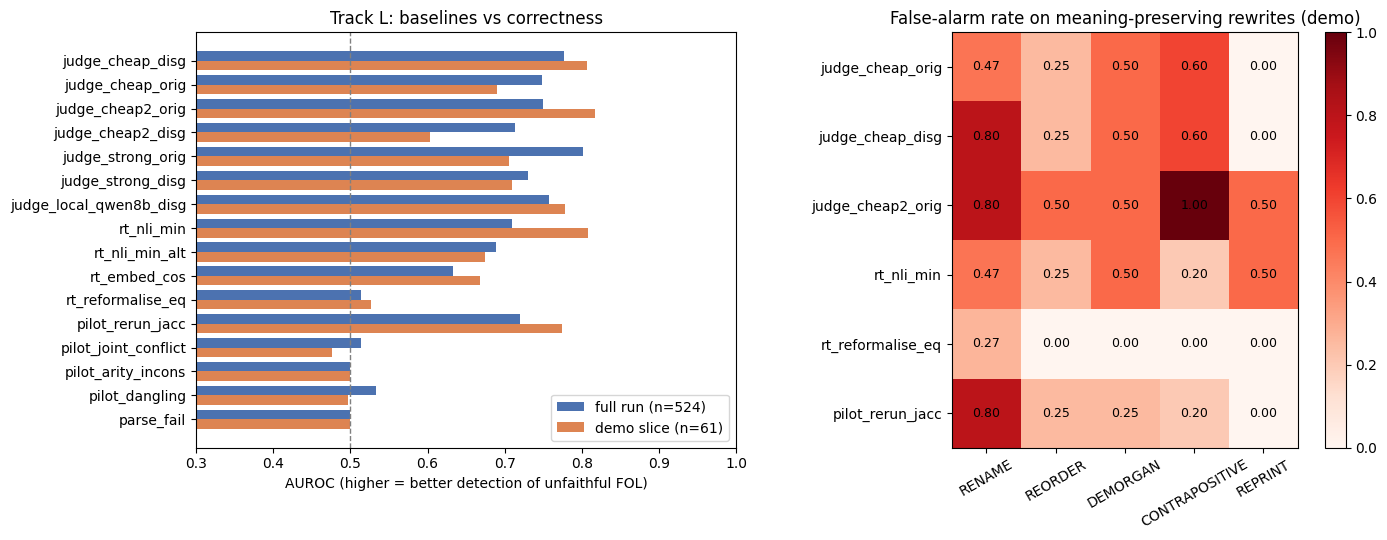

In [36]:
A = jload(RES / "analysis.json")
ref = data["full_run_reference"]
show = ["judge_cheap_disg", "judge_cheap_orig", "judge_cheap2_orig", "judge_cheap2_disg", "judge_strong_orig", "judge_strong_disg",
        "judge_local_qwen8b_disg", "rt_nli_min", "rt_nli_min_alt", "rt_embed_cos", "rt_reformalise_eq", "pilot_rerun_jacc",
        "pilot_joint_conflict", "pilot_arity_incons", "pilot_dangling", "parse_fail"]
rows = []
for sname in ("L_primary", "H_curator_view"):
    R = A["sets"][sname]
    for m in show:
        r = R["metrics"].get(m, {})
        f = ref["auroc"][sname].get(m, {})
        rows.append({"set": sname, "metric": m, "n_applicable": r.get("n_applicable"), "demo_auroc": r.get("auroc"),
                     "demo_ci": (f"[{r['auroc_ci'][0]:.3f}, {r['auroc_ci'][1]:.3f}]" if r.get("auroc_ci") and r["auroc_ci"][0] is not None else None), "full_run_auroc": f.get("auroc")})
df = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print({s: {k: A["sets"][s][k] for k in ("n", "n_pos", "n_neg")} for s in ("L_primary", "H_curator_view")}, "| full run:", ref["n"])
print(df.round(3).to_string(index=False))
cb = A["baseline_combination"]["L_primary"]
print(f"\ncross-fitted combination (track L, demo): " + "; ".join(f"{k}={v['oof_auroc']:.3f}" for k, v in cb.items() if isinstance(v, dict) and "oof_auroc" in v and k != "best"))
print("T8 sanity:", A["T8_sanity"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
d = df[df.set == "L_primary"].dropna(subset=["demo_auroc"])
y = np.arange(len(d))
axes[0].barh(y - 0.2, d.full_run_auroc, height=0.4, label="full run (n=524)", color="#4C72B0")
axes[0].barh(y + 0.2, d.demo_auroc, height=0.4, label=f"demo slice (n={A['sets']['L_primary']['n']})", color="#DD8452")
axes[0].axvline(0.5, color="grey", ls="--", lw=1)
axes[0].set_yticks(y, d.metric); axes[0].invert_yaxis(); axes[0].set_xlim(0.3, 1.0)
axes[0].set_xlabel("AUROC (higher = better detection of unfaithful FOL)"); axes[0].set_title("Track L: baselines vs correctness"); axes[0].legend(loc="lower right")

inv = A["invariance"]["per_metric"]
fams = ["RENAME", "REORDER", "DEMORGAN", "CONTRAPOSITIVE", "REPRINT"]
mets = ["judge_cheap_orig", "judge_cheap_disg", "judge_cheap2_orig", "rt_nli_min", "rt_reformalise_eq", "pilot_rerun_jacc"]
M = np.array([[inv.get(m, {}).get(f, {}).get("fa_rewrite", np.nan) for f in fams] for m in mets], dtype=float)
im = axes[1].imshow(M, cmap="Reds", vmin=0, vmax=1)
axes[1].set_xticks(range(len(fams)), fams, rotation=30); axes[1].set_yticks(range(len(mets)), mets)
for i in range(len(mets)):
    for j in range(len(fams)):
        if not np.isnan(M[i, j]):
            axes[1].text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=9)
axes[1].set_title("False-alarm rate on meaning-preserving rewrites (demo)")
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

In [37]:
print("\n".join((RES / "summary.md").read_text().splitlines()[:40]))
print("\noutputs written:", [p.name for p in WORK.glob("*method_out.json")])

# Experiment D — disguised cheap judge + all baselines: results summary

Label vector sha1 `122d01df41fef9b526c93307489e76a7250c23da` · prereg sha1 `ee5e87478f6a63e96bd3a8308c76bdd38cf05404` · API spend $0.4094

**Deviation / freeze context:** the shared OpenRouter key was exhausted 13:29-15:11 UTC; local open-weight judges (judge_local_*, prereg_local.json) were run meanwhile and are kept as secondary rows. This API prereg was frozen at 15:1x UTC on 2026-09-23 after the OpenRouter key was restored. The local-judge path (prereg_local.json, frozen 13:49 UTC) had ALREADY been joined to track-L labels. No API-judge setting was chosen with track-L information: the rubric variant comes from the dev-slice run of 13:29 UTC (results/promptdev_api_preoutage.json, rule 'higher AUROC, tie -> B' gives A), the strong judge from a cost/validity-only dry run on 10 dev-slice items, and the strong subsample, thresholds, feature sets and bootstrap settings are identical to prereg_local.json.

Judges: ch